<a href="https://colab.research.google.com/github/Fabioaugustmp/ml-politicas-energeticas-ifg-2025/blob/main/CC_ML_TRAINING_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Análise Geoespacial e Modelagem de Potencial Energético em Goiás

Este notebook realiza uma análise geoespacial e modelagem para identificar áreas com alto potencial para implantação de projetos de energia solar e eólica no estado de Goiás, Brasil.

O processo envolve as seguintes etapas principais:

1.  **Preparação da Base Geoespacial (Municípios):** Carregamento e limpeza dos dados geográficos dos municípios de Goiás.
2.  **Processamento e Agregação dos Dados das Usinas (ANEEL):** Integração de dados de usinas existentes por município.
3.  **Processamento e Agregação dos Dados Meteorológicos (INMET):** Associação de dados de radiação solar e vento por município.
4.  **Criação das Variáveis-Alvo:** Desenvolvimento de um score de potencial para energia solar e eólica por município.
5.  **Preparação dos Dados para Modelagem:** Seleção de features e divisão dos dados em conjuntos de treino e teste.
6.  **Treinamento e Avaliação dos Modelos:** Construção, treinamento e avaliação de modelos de Machine Learning para prever o potencial energético.
7.  **Análise de Resultados e Visualização:** Interpretação dos resultados dos modelos e geração de mapas e rankings.

---

## 📦 Importação de Bibliotecas e Instalação de Pacotes

Nesta seção, instalamos os pacotes necessários para a análise geoespacial, manipulação de dados, modelagem e visualização. Em seguida, importamos todas as bibliotecas que serão utilizadas ao longo do notebook.

In [42]:

!pip install geopandas shapely fiona pyproj boto3

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree
import pandas as pd
from scipy.spatial import cKDTree
import boto3
from botocore.client import Config
import io
from botocore import UNSIGNED
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import LineString
import joblib
from sklearn.model_selection import train_test_split, learning_curve

## 🗺️ Passo 1: Preparação da Base Geoespacial (Municípios)

**Objetivo:** Carregar, limpar e enriquecer os dados geográficos dos municípios de Goiás.

**Detalhes:**

*   Carregamos um arquivo shapefile contendo os polígonos dos municípios.
*   Renomeamos colunas para facilitar o uso e selecionamos as informações essenciais (código, nome e geometria).
*   Calculamos a área de cada município em km², utilizando uma projeção adequada para garantir a precisão.
*   Calculamos o centroide de cada município. Estas coordenadas serão usadas posteriormente para associar dados pontuais (como estações meteorológicas e subestações) aos municípios de forma espacial.

Passo 1: Preparação da Base Geoespacial (Microrregiões)
Considerações:
Aqui, construímos a fundação do nosso dataset. Cada linha representará uma microrregião de Goiás, que é a nossa unidade de análise.

Leitura dos Dados: Carregamos o arquivo shapefile que contém os polígonos (as formas geométricas) de cada microrregião.

Limpeza e Seleção: Renomeamos as colunas para um padrão mais limpo e selecionamos apenas as informações essenciais: código, nome e a geometria.

Cálculos Geométricos:

Área: Para calcular a área em km², primeiro convertemos a projeção geográfica (graus) para uma projeção métrica (UTM). Isso garante que o cálculo da área seja preciso.

Centroide: Calculamos o ponto central de cada microrregião. Essas coordenadas serão cruciais para associar dados pontuais, como os das estações meteorológicas.

In [43]:
# ====================================================================================
# PASSO 1: CARREGAR E PREPARAR DADOS DOS MUNICÍPIOS
# ====================================================================================

# Carregue o shapefile dos Municípios de Goiás a partir da URL.
# Este arquivo contém os polígonos de cada município.
gdf_municipios = gpd.read_file('https://ml-politicas-energeticas.s3.us-east-2.amazonaws.com/GO-MICROREGIOES/GO_Municipios_2024.shp')


# --- INSPEÇÃO E LIMPEZA ---
# Vamos inspecionar as colunas para usar os nomes corretos.
print("Nomes originais das colunas do arquivo de municípios:")
print(gdf_municipios.columns)
print("-" * 50)

# Renomeia as colunas de municípios para um padrão limpo (ajuste se os nomes forem diferentes).
# Os nomes comuns são 'CD_MUN' e 'NM_MUN'.
gdf_municipios = gdf_municipios.rename(columns={
    'CD_MUN': 'cd_mun',
    'NM_MUN': 'nm_mun'
})

# Seleciona apenas as colunas de interesse para manter o DataFrame organizado.
# A partir de agora, nossa análise será por MUNICÍPIO.
df_base = gdf_municipios[['cd_mun', 'nm_mun', 'geometry']].copy()


# --- CÁLCULO PRECISO DA ÁREA E DO CENTROIDE ---

# Define o CRS projetado ideal para Goiás (SIRGAS 2000 / UTM zone 22S) para cálculos em metros.
projected_crs = 'EPSG:31982'

# 1. Calcula a área em km², usando a projeção correta para precisão.
df_base['area_km2'] = df_base['geometry'].to_crs(projected_crs).area / 10**6

# 2. Calcula o centroide da forma precisa para EVITAR O WARNING:
#    a. Projeta a geometria para o sistema de metros (UTM).
#    b. Calcula o centroide nesse sistema.
#    c. Converte o ponto do centroide de volta para o sistema geográfico de lat/lon (WGS84).
centroids_geographic = df_base['geometry'].to_crs(projected_crs).centroid.to_crs(df_base.crs)

# 3. Extrai as coordenadas de longitude e latitude do centroide já re-convertido.
df_base['centroid_lon'] = centroids_geographic.x
df_base['centroid_lat'] = centroids_geographic.y

print("\n--- Base de Municípios Pronta (sem avisos) ---")
print(df_base.head())

Nomes originais das colunas do arquivo de municípios:
Index(['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF',
       'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU',
       'NM_CONCU', 'AREA_KM2', 'geometry'],
      dtype='object')
--------------------------------------------------

--- Base de Municípios Pronta (sem avisos) ---
    cd_mun                  nm_mun  \
0  5219902  São Francisco de Goiás   
1  5215652      Palestina de Goiás   
2  5208400             Goianápolis   
3  5207105                 Diorama   
4  5218607                  Rialma   

                                            geometry     area_km2  \
0  POLYGON ((-49.29477 -16.00852, -49.29484 -16.0...   416.562255   
1  POLYGON ((-51.66518 -16.85357, -51.66522 -16.8...  1317.068866   
2  POLYGON ((-48.99706 -16.48599, -48.99716 -16.4...   166.684000   
3  POLYGON ((-51.17175 -16.18246, -51.17179 -16.1...   684.862390   
4  POLYGON ((-49.58194 -15.32987, -49.58211 -15.3..

## ⚡ Passo 2: Processar e Agregar os Dados das Usinas (ANEEL)

**Objetivo:** Integrar informações sobre as usinas de geração de energia existentes em Goiás aos dados dos municípios.

**Detalhes:**

*   Carregamos os dados brutos das usinas da ANEEL a partir de um arquivo CSV.
*   Filtramos os dados para incluir apenas usinas em operação no estado de Goiás.
*   Convertemos as colunas de coordenadas e potência para tipos numéricos, tratando possíveis erros nos dados.
*   Criamos um GeoDataFrame a partir dos dados das usinas, representando cada usina como um ponto geográfico.
*   Realizamos uma junção espacial (`sjoin`) entre as usinas e os municípios para identificar a qual município cada usina pertence.
*   Agregamos os dados por município para calcular o número total de usinas, o número de usinas solares, eólicas e hidrelétricas, bem como a potência total instalada (em MW) e a potência hidrelétrica instalada por município.
*   Mesclamos essas informações agregadas ao DataFrame base dos municípios, preenchendo valores ausentes com zero.

Passo 2: Processar e Agregar os Dados das Usinas (ANEEL)
Considerações:
O objetivo desta etapa é transformar os dados brutos das usinas (pontos em um mapa) em informações úteis para cada microrregião (nossas linhas do DataFrame).

Carregamento e Filtragem: Carregamos os dados da ANEEL e filtramos para manter apenas as usinas em operação no estado de Goiás.

Limpeza de Dados: As coordenadas e a potência vêm como texto com vírgulas. Convertemos essas colunas para um formato numérico para que possam ser usadas em cálculos.

Conversão para GeoDataFrame: Transformamos o DataFrame do pandas em um GeoDataFrame, criando um objeto Point para cada par de coordenadas (latitude/longitude).

Junção Espacial (sjoin): Esta é a operação mais importante aqui. Cruzamos espacialmente as usinas e as microrregiões. O resultado nos diz exatamente a qual microrregião cada usina pertence.

Agregação: Com a junção feita, usamos groupby() para calcular, por microrregião:

O número total de usinas.

O número específico de usinas solares (UFV).

A soma total da potência instalada (convertida para Megawatts).

Merge Final: Unimos essas novas informações ao nosso DataFrame principal. Usamos fillna(0) para garantir que microrregiões sem nenhuma usina registrada recebam o valor zero em vez de NaN (nulo).

In [44]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# --- DADOS E ARQUIVOS ---
url_aneel = 'https://ml-politicas-energeticas.s3.us-east-2.amazonaws.com/ANEEL-SIGA-SISTEMAS-DE-INFORMA%C3%87%C3%83O-GERA%C3%87%C3%83O/siga-empreendimentos-geracao.csv'

# --- LEITURA DOS DADOS ---
df_usinas = pd.read_csv(url_aneel, encoding='ISO-8859-1', sep=';')

# Diagnóstico
print("--- Colunas Disponíveis ---")
print(df_usinas.columns)

# --- FILTRO: Somente usinas de GO e em operação ---
df_usinas_go = df_usinas[
    (df_usinas['SigUFPrincipal'] == 'GO') &
    (df_usinas['DscFaseUsina'] == 'Operação')
].copy()

# --- CONVERSÕES DE TIPO E COORDENADAS ---
df_usinas_go['latitude'] = pd.to_numeric(df_usinas_go['NumCoordNEmpreendimento'].str.replace(',', '.'), errors='coerce')
df_usinas_go['longitude'] = pd.to_numeric(df_usinas_go['NumCoordEEmpreendimento'].str.replace(',', '.'), errors='coerce')
df_usinas_go['potencia_kw'] = pd.to_numeric(df_usinas_go['MdaPotenciaFiscalizadaKw'], errors='coerce')

# Remove usinas sem info válida
df_usinas_go.dropna(subset=['latitude', 'longitude', 'potencia_kw'], inplace=True)

# --- GEODATAFRAME ---
geometry = [Point(xy) for xy in zip(df_usinas_go['longitude'], df_usinas_go['latitude'])]
gdf_usinas_go = gpd.GeoDataFrame(df_usinas_go, crs='EPSG:4326', geometry=geometry)

# Garante que usa o mesmo CRS de df_base
gdf_usinas_go = gdf_usinas_go.to_crs(df_base.crs)

# --- JUNÇÃO ESPACIAL COM MUNICÍPIOS ---
gdf_usinas_por_municipio = gpd.sjoin(gdf_usinas_go, df_base, how="inner", predicate='within')

# --- AGREGAÇÕES ---
# 1. Total de usinas
usinas_total = gdf_usinas_por_municipio.groupby('cd_mun').size().reset_index(name='num_total_usinas')

# 2. Contagens por tipo
usinas_solares = gdf_usinas_por_municipio[gdf_usinas_por_municipio['SigTipoGeracao'] == 'UFV'] \
    .groupby('cd_mun').size().reset_index(name='num_usinas_solares')

usinas_eolica = gdf_usinas_por_municipio[gdf_usinas_por_municipio['SigTipoGeracao'] == 'EOL'] \
    .groupby('cd_mun').size().reset_index(name='num_usinas_eolica')

usinas_hidro_filtradas = gdf_usinas_por_municipio[gdf_usinas_por_municipio['SigTipoGeracao'].isin(['UHE', 'PCH', 'CGH'])]
usinas_hidro = usinas_hidro_filtradas.groupby('cd_mun').size().reset_index(name='num_usinas_hidro')

# 3. Potência total (MW)
usinas_potencia = gdf_usinas_por_municipio.groupby('cd_mun')['potencia_kw'].sum().reset_index()
usinas_potencia['potencia_total_mw'] = usinas_potencia['potencia_kw'] / 1000
usinas_potencia.drop(columns='potencia_kw', inplace=True)

# 4. Potência hidro (MW)
potencia_hidro = usinas_hidro_filtradas.groupby('cd_mun')['potencia_kw'].sum().reset_index()
potencia_hidro['potencia_hidro_mw'] = potencia_hidro['potencia_kw'] / 1000
potencia_hidro.drop(columns='potencia_kw', inplace=True)

# --- CONSOLIDAÇÃO ---
df_final = df_base.copy()
df_final = df_final.merge(usinas_total, on='cd_mun', how='left')
df_final = df_final.merge(usinas_solares, on='cd_mun', how='left')
df_final = df_final.merge(usinas_eolica, on='cd_mun', how='left')
df_final = df_final.merge(usinas_hidro, on='cd_mun', how='left')
df_final = df_final.merge(usinas_potencia, on='cd_mun', how='left')
df_final = df_final.merge(potencia_hidro, on='cd_mun', how='left')

# Preenche nulos com 0 e ajusta tipos
colunas_count = ['num_total_usinas', 'num_usinas_solares', 'num_usinas_eolica', 'num_usinas_hidro']
df_final[colunas_count] = df_final[colunas_count].fillna(0).astype(int)
df_final[['potencia_total_mw', 'potencia_hidro_mw']] = df_final[['potencia_total_mw', 'potencia_hidro_mw']].fillna(0)

# --- VISUALIZAÇÃO ---
print("\n--- Dados Finais por Município ---")
print(df_final[['nm_mun', 'num_total_usinas', 'num_usinas_solares', 'num_usinas_eolica', 'num_usinas_hidro', 'potencia_total_mw', 'potencia_hidro_mw']].head())

display(df_final.head())

joblib.dump(gdf_usinas_por_municipio, 'usinas_por_municipio.joblib')
gdf_usinas_por_municipio.to_parquet('usinas_por_municipio.parquet')


--- Colunas Disponíveis ---
Index(['DatGeracaoConjuntoDados', 'NomEmpreendimento', 'IdeNucleoCEG',
       'CodCEG', 'SigUFPrincipal', 'SigTipoGeracao', 'DscFaseUsina',
       'DscOrigemCombustivel', 'DscFonteCombustivel', 'DscTipoOutorga',
       'NomFonteCombustivel', 'DatEntradaOperacao', 'MdaPotenciaOutorgadaKw',
       'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw',
       'IdcGeracaoQualificada', 'NumCoordNEmpreendimento',
       'NumCoordEEmpreendimento', 'DatInicioVigencia', 'DatFimVigencia',
       'DscPropriRegimePariticipacao', 'DscSubBacia', 'DscMuninicpios'],
      dtype='object')

--- Dados Finais por Município ---
                   nm_mun  num_total_usinas  num_usinas_solares  \
0  São Francisco de Goiás                 0                   0   
1      Palestina de Goiás                 0                   0   
2             Goianápolis                 0                   0   
3                 Diorama                 0                   0   
4                  Rialma 

,cd_mun,nm_mun,geometry,area_km2,centroid_lon,centroid_lat,num_total_usinas,num_usinas_solares,num_usinas_eolica,num_usinas_hidro,potencia_total_mw,potencia_hidro_mw
0,5219902,São Francisco de Goiás,"POLYGON ((-49.29477 -16.00852, -49.29484 -16.0...",416.562255,-49.254686,-15.951452,0,0,0,0,0.0,0.0
1,5215652,Palestina de Goiás,"POLYGON ((-51.66518 -16.85357, -51.66522 -16.8...",1317.068866,-51.441762,-16.704500,0,0,0,0,0.0,0.0
2,5208400,Goianápolis,"POLYGON ((-48.99706 -16.48599, -48.99716 -16.4...",166.684000,-49.066005,-16.515003,0,0,0,0,0.0,0.0
3,5207105,Diorama,"POLYGON ((-51.17175 -16.18246, -51.17179 -16.1...",684.862390,-51.350464,-16.223339,0,0,0,0,0.0,0.0
4,5218607,Rialma,"POLYGON ((-49.58194 -15.32987, -49.58211 -15.3...",268.241005,-49.531672,-15.340756,0,0,0,0,0.0,0.0


## 🔌 Passo 3: Processar Dados de Infraestrutura de Transmissão (ANEEL/ONS)

**Objetivo:** Integrar informações sobre subestações e linhas de transmissão em Goiás aos dados dos municípios.

**Detalhes:**

*   Carregamos os dados das subestações e das linhas de transmissão a partir de arquivos CSV.
*   Filtramos os dados para incluir apenas subestações e linhas localizadas em Goiás.
*   Realizamos merges entre os dados das linhas de transmissão e das subestações para obter as coordenadas geográficas dos terminais de cada linha.
*   Criamos um GeoDataFrame a partir dos dados das linhas de transmissão, representando cada linha como uma linha geométrica (LineString).
*   Realizamos um "corte" espacial (`gpd.overlay`) das linhas de transmissão com os polígonos dos municípios para determinar quais segmentos de linhas passam por cada município.
*   Calculamos o comprimento de cada segmento de linha dentro de cada município.
*   Agregamos o comprimento dos segmentos por município para obter a quilometragem total de linhas de transmissão por município.
*   Mesclamos a informação da quilometragem de linhas de transmissão ao DataFrame principal.

Passo 3: Processar e Agregar os Dados Meteorológicos (INMET)
Considerações:
Dados climáticos são essenciais, mas vêm de estações pontuais. O desafio é atribuir o dado climático mais relevante para cada microrregião, que é uma área.

Simulação/Carregamento: O código assume que os dados de todas as estações já foram carregados e limpos, resultando em um DataFrame com as médias de radiação por estação (radiacao_media_por_estacao) e outro com as coordenadas de cada estação (df_estacoes_info). Você deve substituir o bloco de simulação pelo seu código real que faz isso.

Busca pelo Vizinho Mais Próximo: Esta é a parte mais inteligente. Em vez de um cálculo de distância complexo e lento, usamos uma estrutura de dados otimizada chamada cKDTree.

Criamos uma "árvore" com as coordenadas de todas as estações.

Para cada centroide de microrregião, consultamos a árvore para encontrar o índice (idx) da estação mais próxima de forma quase instantânea.

Atribuição e Merge: Com o índice da estação mais próxima em mãos, simplesmente usamos essa informação para atribuir o nome da estação e, em seguida, fazer um merge para trazer o valor da radiacao_media_anual para nosso DataFrame final.

In [45]:
# ==============================================================================
# PASSO 3 : PROCESSAR DADOS SUBESTAÇÃO
# ==============================================================================

url_subestacao = url_linha_transmissao = 'https://ml-politicas-energeticas.s3.us-east-2.amazonaws.com/subestacao/SUBESTACAO.csv'
df_subestacao = pd.read_csv(url_subestacao, encoding='ISO-8859-1', sep=';')

df_subestacao_go = df_subestacao[df_subestacao['id_estado'] == 'GO'].copy()

display(df_subestacao.head())
display(df_subestacao_go.head())

,id_subsistema,nom_subsistema,id_estado,nom_estado,nom_agente_principal,id_subestacao,nom_subestacao,val_niveltensao,id_estacao,num_barra,val_latitude,val_longitude
0,N,Norte,AM,Amazonas,ENERGISA AMAZONAS,AMCR-1,CRISTIANO ROCHA,230.0,AMCR--21,8551.0,-2.892752,-60.032086
1,N,Norte,AM,Amazonas,ENERGISA AMAZONAS,AMJTX,JORG.TEIXEIRA,138.0,AMJTX-1A,8512.0,-3.020900,-59.896500
2,N,Norte,AM,Amazonas,ENERGISA AMAZONAS,AMJTX,JORG.TEIXEIRA,230.0,AMJTX-2A,8511.0,-3.020900,-59.896500
3,N,Norte,AM,Amazonas,MANAUS TR,AMCRR,LECHUGA,138.0,AMCRR-1A,8751.0,-2.920154,-60.014645
4,N,Norte,AM,Amazonas,MANAUS TR,AMCRR,LECHUGA,230.0,AMCRR-2A,8700.0,-2.920154,-60.014645


,id_subsistema,nom_subsistema,id_estado,nom_estado,nom_agente_principal,id_subestacao,nom_subestacao,val_niveltensao,id_estacao,num_barra,val_latitude,val_longitude
1137,SE,Sudeste/Centro-Oeste,GO,GoiÃ¡s,EDP GOIAS,GOALD,AGUAS LINDAS,69.0,GOALD-0A,2974.0,-15.767778,-48.275278
1138,SE,Sudeste/Centro-Oeste,GO,GoiÃ¡s,EDP GOIAS,GOALD,AGUAS LINDAS,230.0,GOALD-2A,2987.0,-15.767778,-48.275278
1139,SE,Sudeste/Centro-Oeste,GO,GoiÃ¡s,EDP GOIAS,GOANH,ANHANGUERA,69.0,GOANH-0B,762.0,-16.789400,-49.236698
1140,SE,Sudeste/Centro-Oeste,GO,GoiÃ¡s,EDP GOIAS,GOANH,ANHANGUERA,138.0,GOANH-1A,761.0,-16.789400,-49.236698
1141,SE,Sudeste/Centro-Oeste,GO,GoiÃ¡s,EDP GOIAS,GOANH,ANHANGUERA,230.0,GOANH-2A,760.0,-16.789400,-49.236698


In [46]:
# ==============================================================================
# PASSO 3 : PROCESSAR DADOS LINHAS DE TRANSMISSÃO
# ==============================================================================

url_linha_transmissao = 'https://ml-politicas-energeticas.s3.us-east-2.amazonaws.com/ONS-LINHAS-DE-TRANSMISSAO-REDE-DE-OPERACAO/LINHA_TRANSMISSAO.csv'
df_linha_transmissao = pd.read_csv(url_linha_transmissao, encoding='ISO-8859-1', sep=';')

df_linha_transmissao_go = df_linha_transmissao[
    (df_linha_transmissao['id_estado_terminalde'] == 'GO')
    & (df_linha_transmissao['id_estado_terminalpara'] == 'GO')
].copy()

display(df_linha_transmissao.head())
display(df_linha_transmissao_go.head())

# Valor em medido em KM
# display(df_linha_transmissao_go['val_comprimento'])

,id_subsistema_terminalde,nom_subsistema_terminalde,id_subsistema_terminalpara,nom_subsistema_terminalpara,id_estado_terminalde,nom_estado_de,id_estado_terminalpara,nom_estado_para,nom_subestacao_de,nom_subestacao_para,...,val_capacidadeoperveraodialonga,val_capacidadeoperveraonoitelonga,val_capacoperinvernodialonga,val_capacoperinvernonoitelonga,val_capacoperveradiacurta,val_capacoperveraonoitecurta,val_capacoperinvernodiacurta,val_capacoperinvernonoitecurta,num_barra_de,num_barra_para
0,SE,SUDESTE,SE,SUDESTE,AC,ACRE,AC,ACRE,CRUZEIRO SUL,FEIJO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6990.0,6980.0
1,SE,SUDESTE,SE,SUDESTE,AC,ACRE,AC,ACRE,FEIJO,RIO BRANCO I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6980.0,6950.0
2,SE,SUDESTE,SE,SUDESTE,AC,ACRE,AC,ACRE,RIO BRANCO I,TUCUMA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6950.0,7031.0
3,NE,NORDESTE,NE,NORDESTE,AL,ALAGOAS,AL,ALAGOAS,ARAPIRACA III,PENEDO,...,631.0,663.0,631.0,663.0,795.0,869.0,795.0,825.0,6081.0,5291.0
4,NE,NORDESTE,NE,NORDESTE,AL,ALAGOAS,AL,ALAGOAS,ARAPIRACA III,RIO LARGO II,...,631.0,663.0,631.0,663.0,795.0,870.0,795.0,824.0,6081.0,5111.0


,id_subsistema_terminalde,nom_subsistema_terminalde,id_subsistema_terminalpara,nom_subsistema_terminalpara,id_estado_terminalde,nom_estado_de,id_estado_terminalpara,nom_estado_para,nom_subestacao_de,nom_subestacao_para,...,val_capacidadeoperveraodialonga,val_capacidadeoperveraonoitelonga,val_capacoperinvernodialonga,val_capacoperinvernonoitelonga,val_capacoperveradiacurta,val_capacoperveraonoitecurta,val_capacoperinvernodiacurta,val_capacoperinvernonoitecurta,num_barra_de,num_barra_para
318,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,760.0,226.0
319,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,1100.0,760.0,226.0
320,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,C. DOURADA,...,550.0,550.0,550.0,550.0,550.0,599.0,557.0,637.0,760.0,749.0
321,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,C. DOURADA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,760.0,749.0
322,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,CARAJAS,...,550.0,550.0,550.0,550.0,781.0,781.0,781.0,781.0,760.0,3714.0


In [47]:
# ==============================================================================
# PASSO 3: MERGE LINHAS E SUBESTAÇÕES (VERSÃO CORRIGIDA)
# ==============================================================================

print("\nColunas Linhas Transmissão:", df_linha_transmissao_go.columns)
print("\nColunas Subestações:", df_subestacao_go.columns)

col_linha_de = 'nom_subestacao_de'
col_linha_ate = 'nom_subestacao_para'
col_subestacao = 'nom_subestacao'

# Nomes das colunas de coordenadas no df_subestacao_go
# (Ajuste se forem diferentes, ex: 'val_latitude_Y' e 'val_latitude_x')
col_coord_lat = 'val_latitude'
col_coord_lon = 'val_longitude'

# --- Seleciona coordenadas ---
df_coords_subestacoes = df_subestacao_go[[
    col_subestacao,
    col_coord_lat,
    col_coord_lon
]].copy()


# --- MERGE 1: BUSCAR COORDENADAS DE ORIGEM (DE) ---
print(f"Realizando Merge 1 (Origem) usando '{col_linha_de}' e '{col_subestacao}'...")

df_transmissao_go = pd.merge(
    df_linha_transmissao_go,
    df_coords_subestacoes,
    left_on=col_linha_de,
    right_on=col_subestacao,
    how='inner'
)

df_transmissao_go = df_transmissao_go.rename(columns={
    col_coord_lat: 'lat_de',
    col_coord_lon: 'lon_de'
})

# Remove a coluna 'nom_subestacao' para evitar conflito no próximo merge
df_transmissao_go = df_transmissao_go.drop(columns=[col_subestacao])

# --- MERGE 2: BUSCAR COORDENADAS DE DESTINO (ATE) ---
print(f"Realizando Merge 2 (Destino) usando '{col_linha_ate}' e '{col_subestacao}'...")

df_transmissao_go = pd.merge(
    df_transmissao_go,
    df_coords_subestacoes,
    left_on=col_linha_ate,
    right_on=col_subestacao,
    how='inner'
)

df_transmissao_go = df_transmissao_go.rename(columns={
    col_coord_lat: 'lat_ate',
    col_coord_lon: 'lon_ate'
})

# Remove a coluna 'nom_subestacao' final
df_transmissao_go = df_transmissao_go.drop(columns=[col_subestacao])

# --- Verificação Final ---
print("\nDataFrame final das linhas de transmissão com coordenadas:")
display(df_transmissao_go.head())

if all(col in df_transmissao_go.columns for col in ['lat_de', 'lon_de', 'lat_ate', 'lon_ate']):
    display(df_transmissao_go[['nom_subestacao_de', 'lat_de', 'lon_de', 'nom_subestacao_para', 'lat_ate', 'lon_ate']].head())
else:
    print("ERRO: Uma ou mais colunas de coordenadas não foram criadas. Verifique os nomes das colunas.")
    print("\nColunas atuais:", df_transmissao_go.columns)

# joblib.dump(df_linha_transmissao_go, 'linhas_por_municipio.joblib')
# df_linha_transmissao_go.to_parquet('linhas_por_municipio.parquet')


Colunas Linhas Transmissão: Index(['id_subsistema_terminalde', 'nom_subsistema_terminalde',
       'id_subsistema_terminalpara', 'nom_subsistema_terminalpara',
       'id_estado_terminalde', 'nom_estado_de', 'id_estado_terminalpara',
       'nom_estado_para', 'nom_subestacao_de', 'nom_subestacao_para',
       'val_niveltensao_kv', 'nom_tipoderede', 'nom_tipolinha',
       'nom_agenteproprietario', 'nom_linhadetransmissao', 'cod_equipamento',
       'dat_entradaoperacao', 'dat_desativacao', 'dat_prevista',
       'val_comprimento', 'val_resistencia', 'val_reatancia', 'val_shunt',
       'val_capacoperlongasemlimit', 'val_capacoperlongacomlimit',
       'val_capacopercurtasemlimit', 'val_capacopercurtacomlimit',
       'val_capacidadeoperveraodialonga', 'val_capacidadeoperveraonoitelonga',
       'val_capacoperinvernodialonga', 'val_capacoperinvernonoitelonga',
       'val_capacoperveradiacurta', 'val_capacoperveraonoitecurta',
       'val_capacoperinvernodiacurta', 'val_capacoperinvern

,id_subsistema_terminalde,nom_subsistema_terminalde,id_subsistema_terminalpara,nom_subsistema_terminalpara,id_estado_terminalde,nom_estado_de,id_estado_terminalpara,nom_estado_para,nom_subestacao_de,nom_subestacao_para,...,val_capacoperveradiacurta,val_capacoperveraonoitecurta,val_capacoperinvernodiacurta,val_capacoperinvernonoitecurta,num_barra_de,num_barra_para,lat_de,lon_de,lat_ate,lon_ate
0,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,760.0,226.0,-16.7894,-49.236698,-16.793335,-49.233715
1,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,760.0,226.0,-16.7894,-49.236698,-16.793335,-49.233715
2,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,760.0,226.0,-16.7894,-49.236698,-16.793335,-49.233715
3,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,760.0,226.0,-16.7894,-49.236698,-16.793335,-49.233715
4,SE,SUDESTE,SE,SUDESTE,GO,GOIAS,GO,GOIAS,ANHANGUERA,BANDEIRANTES,...,1100.0,1100.0,1100.0,1100.0,760.0,226.0,-16.7894,-49.236698,-16.793335,-49.233715


,nom_subestacao_de,lat_de,lon_de,nom_subestacao_para,lat_ate,lon_ate
0,ANHANGUERA,-16.7894,-49.236698,BANDEIRANTES,-16.793335,-49.233715
1,ANHANGUERA,-16.7894,-49.236698,BANDEIRANTES,-16.793335,-49.233715
2,ANHANGUERA,-16.7894,-49.236698,BANDEIRANTES,-16.793335,-49.233715
3,ANHANGUERA,-16.7894,-49.236698,BANDEIRANTES,-16.793335,-49.233715
4,ANHANGUERA,-16.7894,-49.236698,BANDEIRANTES,-16.793335,-49.233715


## ☀️ Passo 3.5: Processar e Agregar Dados Meteorológicos (INMET)

**Objetivo:** Carregar, limpar e associar dados de radiação solar, vento e temperatura das estações meteorológicas do INMET aos municípios de Goiás.

**Detalhes:**

*   Acessamos e baixamos dados meteorológicos de arquivos CSV armazenados em um bucket S3, filtrando por anos recentes.
*   Para cada arquivo, extraímos informações da estação (nome, código, latitude, longitude) a partir do cabeçalho.
*   Lemos os dados horários de cada estação, tratando a separação decimal e convertendo colunas numéricas.
*   Concatenamos os dados de todas as estações em um único DataFrame.
*   Calculamos as médias anuais de radiação global, velocidade do vento e temperatura para cada estação.
*   Utilizamos uma estrutura de dados otimizada (`cKDTree`) para encontrar a estação meteorológica mais próxima do centroide de cada município.
*   Atribuímos os dados meteorológicos da estação mais próxima a cada município no DataFrame principal.

In [48]:
# ==============================================================================
# PASSO 3.5: PROCESSAR E AGREGAR DADOS DE LINHAS DE TRANSMISSÃO
# ==============================================================================
from shapely.geometry import LineString

df_linhas_go = df_transmissao_go.copy()

print("\n--- Colunas das Linhas de Transmissão ---")
print(df_linhas_go.columns)
print("------------------------------------------")

COL_LAT_DE = 'lat_de'
COL_LON_DE = 'lon_de'
COL_LAT_ATE = 'lat_ate'
COL_LON_ATE = 'lon_ate'

# Remove linhas onde qualquer coordenada é nula
df_linhas_go.dropna(subset=[COL_LAT_DE, COL_LON_DE, COL_LAT_ATE, COL_LON_ATE], inplace=True)

# --- 3. CRIAÇÃO DO GEODATAFRAME DE LINHAS ---
try:
    # Cria a geometria 'LineString' para cada linha
    geometry = [
        LineString([
            (row[COL_LON_DE], row[COL_LAT_DE]),  # Ponto inicial (lon, lat)
            (row[COL_LON_ATE], row[COL_LAT_ATE]) # Ponto final (lon, lat)
        ])
        for index, row in df_linhas_go.iterrows()
    ]

    # Cria o GeoDataFrame
    gdf_linhas = gpd.GeoDataFrame(df_linhas_go, crs='EPSG:4326', geometry=geometry)

    # Garante o mesmo CRS do df_final (municípios)
    gdf_linhas = gdf_linhas.to_crs(df_final.crs)

    print(f"\n{len(gdf_linhas)} linhas de transmissão convertidas para GeoDataFrame.")

    # --- 4. CLIPPING (CORTE) ESPACIAL DAS LINHAS ---
    print("Calculando interseção das linhas com os municípios (pode demorar um pouco)...")

    # gpd.overlay 'intersection' vai "cortar" as linhas nas fronteiras dos municípios
    gdf_linhas_clipped = gpd.overlay(gdf_linhas, df_final, how='intersection')

    # --- 5. CÁLCULO DO COMPRIMENTO DO SEGMENTO ---
    # Projeta para UTM (EPSG:31982) para calcular o comprimento em METROS
    projected_crs = 'EPSG:31982'
    gdf_linhas_clipped['comprimento_segmento_m'] = gdf_linhas_clipped.geometry.to_crs(projected_crs).length

    # Converte para KM
    gdf_linhas_clipped['comprimento_segmento_km'] = gdf_linhas_clipped['comprimento_segmento_m'] / 1000

    # --- 6. AGREGAÇÃO POR MUNICÍPIO ---
    # Agrupa pelo código do município e SOMA o comprimento de todos os segmentos dentro dele
    km_linhas_por_mun = gdf_linhas_clipped.groupby('cd_mun')['comprimento_segmento_km'].sum().reset_index(name='km_linhas_transmissao')

    # --- 7. MERGE FINAL ---
    cols_to_drop = ['km_linhas_transmissao', 'km_linhas_transmissao_x', 'km_linhas_transmissao_y']
    cols_existentes_para_remover = [col for col in cols_to_drop if col in df_final.columns]

    if cols_existentes_para_remover:
        print(f"Limpando colunas antigas: {cols_existentes_para_remover}")
        df_final = df_final.drop(columns=cols_existentes_para_remover)

    # Junta a nova coluna 'km_linhas_transmissao' ao DataFrame principal
    df_final = df_final.merge(km_linhas_por_mun, on='cd_mun', how='left')

    # Municípios sem linhas de transmissão receberão 0
    df_final['km_linhas_transmissao'] = df_final['km_linhas_transmissao'].fillna(0)

    print("\n--- Junção de Linhas de Transmissão Concluída ---")
    display(df_final[['nm_mun', 'km_linhas_transmissao']].sort_values(by='km_linhas_transmissao', ascending=False).head())
    display(df_final.head())

except Exception as e:
    print(f"\nOcorreu um erro ao processar as linhas de transmissão: {e}")
    # Adiciona a coluna com 0 para não quebrar os passos seguintes
    if 'km_linhas_transmissao' not in df_final.columns:
        df_final['km_linhas_transmissao'] = 0.0


gdf_linhas_clipped.to_parquet('linhas_por_municipio.parquet')


--- Colunas das Linhas de Transmissão ---
Index(['id_subsistema_terminalde', 'nom_subsistema_terminalde',
       'id_subsistema_terminalpara', 'nom_subsistema_terminalpara',
       'id_estado_terminalde', 'nom_estado_de', 'id_estado_terminalpara',
       'nom_estado_para', 'nom_subestacao_de', 'nom_subestacao_para',
       'val_niveltensao_kv', 'nom_tipoderede', 'nom_tipolinha',
       'nom_agenteproprietario', 'nom_linhadetransmissao', 'cod_equipamento',
       'dat_entradaoperacao', 'dat_desativacao', 'dat_prevista',
       'val_comprimento', 'val_resistencia', 'val_reatancia', 'val_shunt',
       'val_capacoperlongasemlimit', 'val_capacoperlongacomlimit',
       'val_capacopercurtasemlimit', 'val_capacopercurtacomlimit',
       'val_capacidadeoperveraodialonga', 'val_capacidadeoperveraonoitelonga',
       'val_capacoperinvernodialonga', 'val_capacoperinvernonoitelonga',
       'val_capacoperveradiacurta', 'val_capacoperveraonoitecurta',
       'val_capacoperinvernodiacurta', 'val_c

,nm_mun,km_linhas_transmissao
80,Niquelândia,1228.922142
152,Palmeiras de Goiás,895.262757
183,Rio Verde,873.044529
238,Morrinhos,689.028121
229,Trindade,666.995106


,cd_mun,nm_mun,geometry,area_km2,centroid_lon,centroid_lat,num_total_usinas,num_usinas_solares,num_usinas_eolica,num_usinas_hidro,potencia_total_mw,potencia_hidro_mw,km_linhas_transmissao
0,5219902,São Francisco de Goiás,"POLYGON ((-49.29477 -16.00852, -49.29484 -16.0...",416.562255,-49.254686,-15.951452,0,0,0,0,0.0,0.0,0.000000
1,5215652,Palestina de Goiás,"POLYGON ((-51.66518 -16.85357, -51.66522 -16.8...",1317.068866,-51.441762,-16.704500,0,0,0,0,0.0,0.0,0.000000
2,5208400,Goianápolis,"POLYGON ((-48.99706 -16.48599, -48.99716 -16.4...",166.684000,-49.066005,-16.515003,0,0,0,0,0.0,0.0,101.583939
3,5207105,Diorama,"POLYGON ((-51.17175 -16.18246, -51.17179 -16.1...",684.862390,-51.350464,-16.223339,0,0,0,0,0.0,0.0,0.000000
4,5218607,Rialma,"POLYGON ((-49.58194 -15.32987, -49.58211 -15.3...",268.241005,-49.531672,-15.340756,0,0,0,0,0.0,0.0,0.000000


In [49]:
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

bucket = 'ml-politicas-energeticas'
prefix = 'inmet/'

try:
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix, MaxKeys=5)
    for obj in resp.get('Contents', []):
        print(obj['Key'])
except Exception as e:
    print("Error:", e)

inmet/2001/INMET_CO_GO_A002_GOIANIA_29-05-2001_A_31-12-2001.CSV
inmet/2001/INMET_CO_GO_A003_MORRINHOS_25-05-2001_A_31-12-2001.CSV
inmet/2002/INMET_CO_GO_A002_GOIANIA_01-01-2002_A_31-12-2002.CSV
inmet/2002/INMET_CO_GO_A003_MORRINHOS_01-01-2002_A_31-12-2002.CSV
inmet/2003/INMET_CO_GO_A002_GOIANIA_01-01-2003_A_31-12-2003.CSV


In [50]:
# ==============================================================================
# PASSO 3: PROCESSAR DADOS METEOROLÓGICOS DO S3 - INMET
# ==============================================================================
s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))
bucket_name = 'ml-politicas-energeticas'
prefix = 'inmet/'

allowed_years = ['inmet/2025', 'inmet/2024', 'inmet/2023', 'inmet/2022', 'inmet/2021']

resp = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
all_csv_files = resp.get('Contents', [])

all_data_frames = []
all_station_info = []

for file_key in all_csv_files:
    try:
        file_path = file_key['Key']

        # Skip files inside the 'inmet/BKP/' folder
        if 'inmet/BKP/' in file_path:
            print(f"Pulando arquivo de backup: {file_path}")
            continue

        if not any(year in file_path for year in allowed_years):
            print(f"Skipping file (not in allowed years): {file_path}")
            continue  # skip files not matching allowed years

        print(f"Baixando: {file_path}")

        response = s3_client.get_object(Bucket=bucket_name, Key=file_path)
        content = response['Body'].read().decode('latin-1')
        file_in_memory = io.StringIO(content)

        # Lê cabeçalho de 8 linhas
        header_lines = [next(file_in_memory) for _ in range(8)]
        station_name = header_lines[2].split(';')[1].strip()
        station_code = header_lines[3].split(';')[1].strip()
        latitude = header_lines[4].split(';')[1].replace(',', '.').strip()
        longitude = header_lines[5].split(';')[1].replace(',', '.').strip()

        all_station_info.append({
            'Nome': station_name,
            'codigo_estacao': station_code,
            'Latitude': latitude,
            'Longitude': longitude
        })

        df_inmet = pd.read_csv(
            file_in_memory,
            sep=';',
            skiprows=0,
            encoding='latin-1',
            decimal=',',
            dtype=str,  # tudo como string
        )

        # Remove colunas desnecessárias ou de código de estação
        if df_inmet.columns[0].startswith('Unnamed') or df_inmet.columns[0] == '':
            df_inmet = df_inmet.iloc[:, 1:]

        # Converte colunas numéricas, ignorando erros
        for col in df_inmet.columns[1:]:  # ignora coluna de data
            df_inmet[col] = pd.to_numeric(df_inmet[col].str.replace(',', '.'), errors='coerce')

        df_inmet['Estacao'] = station_name
        df_inmet['latitude'] = latitude
        df_inmet['longitude'] = longitude
        df_inmet['codigo_estacao'] = station_code

        all_data_frames.append(df_inmet)

    except Exception as e:
        print(f"Erro ao processar {file_path}: {e}")

# Consolida
df_clima_completo = pd.concat(all_data_frames, ignore_index=True)
df_estacoes_info = pd.DataFrame(all_station_info).drop_duplicates().reset_index(drop=True)

# Join
df_clima_completo = pd.merge(
    df_clima_completo,
    df_estacoes_info,
    on='codigo_estacao',
    how='left',
    suffixes=('', '_info')
)

joblib.dump(df_clima_completo, 'clima_completo.joblib')
df_clima_completo.to_parquet('clima_completo.parquet')


Skipping file (not in allowed years): inmet/2001/INMET_CO_GO_A002_GOIANIA_29-05-2001_A_31-12-2001.CSV
Skipping file (not in allowed years): inmet/2001/INMET_CO_GO_A003_MORRINHOS_25-05-2001_A_31-12-2001.CSV
Skipping file (not in allowed years): inmet/2002/INMET_CO_GO_A002_GOIANIA_01-01-2002_A_31-12-2002.CSV
Skipping file (not in allowed years): inmet/2002/INMET_CO_GO_A003_MORRINHOS_01-01-2002_A_31-12-2002.CSV
Skipping file (not in allowed years): inmet/2003/INMET_CO_GO_A002_GOIANIA_01-01-2003_A_31-12-2003.CSV
Skipping file (not in allowed years): inmet/2003/INMET_CO_GO_A003_MORRINHOS_01-01-2003_A_31-12-2003.CSV
Skipping file (not in allowed years): inmet/2004/INMET_CO_GO_A002_GOIANIA_01-01-2004_A_31-12-2004.CSV
Skipping file (not in allowed years): inmet/2004/INMET_CO_GO_A003_MORRINHOS_01-01-2004_A_31-12-2004.CSV
Skipping file (not in allowed years): inmet/2005/INMET_CO_GO_A002_GOIANIA_01-01-2005_A_31-12-2005.CSV
Skipping file (not in allowed years): inmet/2005/INMET_CO_GO_A003_MORRINHO

In [51]:
del all_data_frames
del all_station_info

In [52]:
df_estacoes_info.head()

,Nome,codigo_estacao,Latitude,Longitude
0,GOIANIA,A002,-16.642841,-49.220222
1,MORRINHOS,A003,-17.745066,-49.101698
2,PORANGATU,A005,-13.30944444,-49.11749999
3,SAO SIMAO,A011,-18.969142,-50.633449
4,LUZIANIA,A012,-16.26055555,-47.96694443


In [53]:
df_clima_completo.head()

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,"VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19,Estacao,latitude,longitude,codigo_estacao,Nome,Latitude,Longitude
0,2021/01/01,NaN,0.0,932.5,932.5,931.5,NaN,21.9,20.0,22.6,...,2.5,0.3,NaN,GOIANIA,-16.642841,-49.220222,A002,GOIANIA,-16.642841,-49.220222
1,2021/01/01,NaN,0.0,932.5,932.5,931.5,NaN,21.9,20.0,22.6,...,2.5,0.3,NaN,GOIANIA,-16.642841,-49.220222,A002,GOIANIA,-16.64277777,-49.22027777
2,2021/01/01,NaN,0.0,932.8,932.8,932.5,NaN,22.4,20.8,22.4,...,1.4,0.5,NaN,GOIANIA,-16.642841,-49.220222,A002,GOIANIA,-16.642841,-49.220222
3,2021/01/01,NaN,0.0,932.8,932.8,932.5,NaN,22.4,20.8,22.4,...,1.4,0.5,NaN,GOIANIA,-16.642841,-49.220222,A002,GOIANIA,-16.64277777,-49.22027777
4,2021/01/01,NaN,0.0,932.8,932.9,932.7,NaN,22.7,20.2,22.8,...,1.6,0.8,NaN,GOIANIA,-16.642841,-49.220222,A002,GOIANIA,-16.642841,-49.220222


In [54]:
coluna_radiacao = [col for col in df_clima_completo.columns if 'RADIACAO' in col][0]
coluna_vento = [col for col in df_clima_completo.columns if 'VENTO, VELOCIDADE' in col][0]
coluna_temp = [col for col in df_clima_completo.columns if 'TEMPERATURA DO AR' in col][0]

# Subset df_clima_completo to only relevant columns
df_clima_subset = df_clima_completo[['Estacao', coluna_radiacao, coluna_vento, coluna_temp]]

# Aggregate all means in one groupby
aggregations = {
    coluna_radiacao: 'mean',
    coluna_vento: 'mean',
    coluna_temp: 'mean'
}
df_medias = df_clima_subset.groupby('Estacao').agg(aggregations).reset_index()

# Rename columns
df_medias = df_medias.rename(columns={
    coluna_radiacao: 'radiacao_media_anual',
    coluna_vento: 'vento_media_anual',
    coluna_temp: 'temp_media_anual'
})

# Rename 'Nome' to 'Estacao' in df_estacoes_info
df_estacoes_info = df_estacoes_info.rename(columns={'Nome': 'Estacao'})

# Drop existing mean columns if they exist
cols_to_drop = ['radiacao_media_anual', 'vento_media_anual', 'temp_media_anual']
cols_to_drop = [col for col in cols_to_drop if col in df_estacoes_info.columns]
df_estacoes_info = df_estacoes_info.drop(columns=cols_to_drop)

# Set index and join
df_estacoes_info = df_estacoes_info.set_index('Estacao')
df_medias = df_medias.set_index('Estacao')

df_estacoes_final = df_estacoes_info.join(df_medias, how='left').reset_index()

# Show result
display(df_estacoes_final.head())
print(f"\nDados de {df_estacoes_final.shape[0]} estações meteorológicas carregados com sucesso.")

df_linha_transmissao_go.to_parquet('linhas_por_municipio.parquet')


,Estacao,codigo_estacao,Latitude,Longitude,radiacao_media_anual,vento_media_anual,temp_media_anual
0,GOIANIA,A002,-16.642841,-49.220222,1384.524287,0.913829,23.962746
1,MORRINHOS,A003,-17.745066,-49.101698,1414.289535,1.486442,23.187612
2,PORANGATU,A005,-13.30944444,-49.11749999,1511.559184,1.055559,26.908896
3,SAO SIMAO,A011,-18.969142,-50.633449,881.463367,1.459167,24.944819
4,LUZIANIA,A012,-16.26055555,-47.96694443,1512.191922,2.038582,22.701930



Dados de 33 estações meteorológicas carregados com sucesso.


In [55]:
display(df_clima_completo.columns)

Index(['Data', 'Hora UTC', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)', 'Unnamed: 19', 'Estacao', 'latitude',
       'longitude', 'codigo_estacao', 'Nome', 'Latitude', 'Longitude'],
      dtype='object

In [56]:
# ==============================================================================
# PASSO 3.8: JUNTAR DADOS METEOROLÓGICOS (cKDTree)
# ==============================================================================
from scipy.spatial import cKDTree

# 1. Prepara os dados das estações
# Garante que as coordenadas sejam numéricas
df_estacoes_final['Latitude'] = pd.to_numeric(df_estacoes_final['Latitude'], errors='coerce')
df_estacoes_final['Longitude'] = pd.to_numeric(df_estacoes_final['Longitude'], errors='coerce')

# Remove estações sem coordenadas válidas
df_estacoes_validas = df_estacoes_final.dropna(subset=['Latitude', 'Longitude']).copy()

# Cria um array com as coordenadas (lat, lon) das estações
coordenadas_estacoes = df_estacoes_validas[['Latitude', 'Longitude']].values

# 2. Prepara os dados dos municípios
# Cria um array com os centroides (lat, lon) dos municípios
coordenadas_municipios = df_final[['centroid_lat', 'centroid_lon']].values

# 3. Constrói a Árvore cKDTree
# Cria a árvore a partir das coordenadas das ESTAÇÕES
print("Construindo árvore cKDTree das estações meteorológicas...")
tree = cKDTree(coordenadas_estacoes)

# 4. Consulta a Árvore
# Para cada município, encontra o índice (idx) da estação mais próxima
# 'dist' = distância, 'idx' = índice da estação no array 'coordenadas_estacoes'
print("Buscando estação mais próxima para cada município...")
dist, idx = tree.query(coordenadas_municipios, k=1)

# 5. Atribui a estação mais próxima ao df_final
# Usa o 'idx' para pegar o nome da estação correspondente do 'df_estacoes_validas'
df_final['estacao_mais_proxima'] = df_estacoes_validas.iloc[idx]['Estacao'].values

# 6. Merge Final
# Agora, junta os dados meteorológicos (vento, radiação) ao df_final
# usando o nome da estação como chave.
df_final = pd.merge(
    df_final,
    df_estacoes_validas[['Estacao', 'radiacao_media_anual', 'vento_media_anual', 'temp_media_anual']],
    left_on='estacao_mais_proxima',
    right_on='Estacao',
    how='left'
)

# Limpa colunas desnecessárias do merge
df_final = df_final.drop(columns=['Estacao'])

# Preenche com 0 municípios que não encontraram dados
cols_meteo = ['radiacao_media_anual', 'vento_media_anual', 'temp_media_anual']
df_final[cols_meteo] = df_final[cols_meteo].fillna(0)

print("\n--- Junção de dados meteorológicos concluída! ---")
display(df_final[['nm_mun', 'estacao_mais_proxima', 'radiacao_media_anual', 'vento_media_anual']].head())

Construindo árvore cKDTree das estações meteorológicas...
Buscando estação mais próxima para cada município...

--- Junção de dados meteorológicos concluída! ---


,nm_mun,estacao_mais_proxima,radiacao_media_anual,vento_media_anual
0,São Francisco de Goiás,GOIANIA,1384.524287,0.913829
1,São Francisco de Goiás,GOIANIA,1384.524287,0.913829
2,Palestina de Goiás,IPORA,1542.553056,1.989082
3,Goianápolis,GOIANIA,1384.524287,0.913829
4,Goianápolis,GOIANIA,1384.524287,0.913829


### Análise de Dados de Agregação mensal


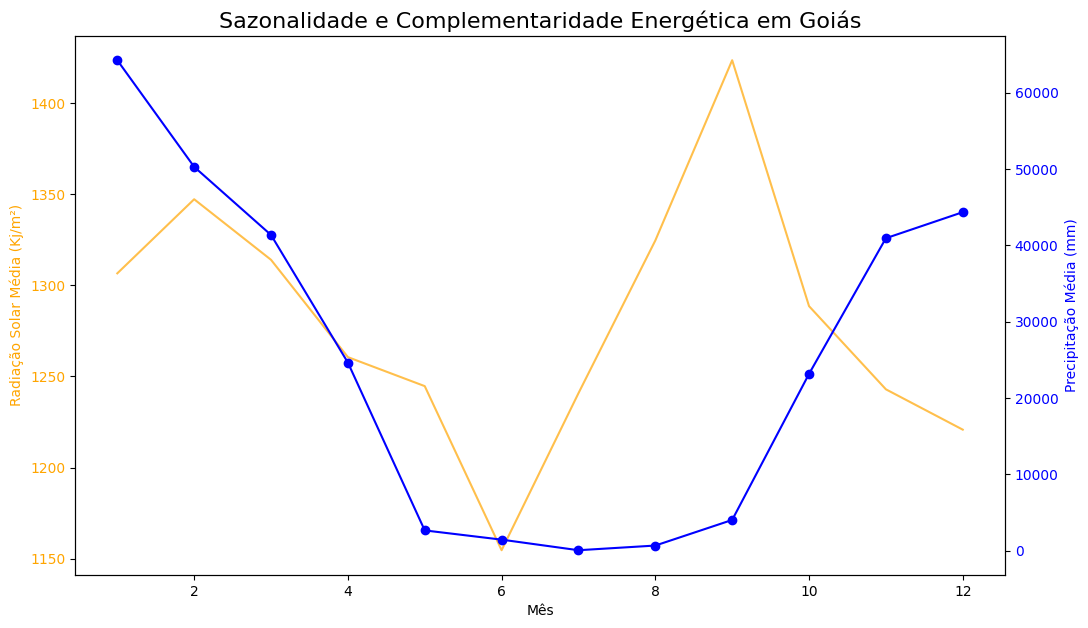

In [57]:
df_clima_completo['Data'] = pd.to_datetime(df_clima_completo['Data'], format='%Y/%m/%d')
df_clima_completo['Mes'] = df_clima_completo['Data'].dt.month

# Agregação mensal
radiacao_mensal = df_clima_completo.groupby('Mes')['RADIACAO GLOBAL (Kj/m²)'].mean()
chuva_mensal = df_clima_completo.groupby('Mes')['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].sum() # Ou a métrica de chuva disponível

# Gráfico de Sazonalidade
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Mês')
ax1.set_ylabel('Radiação Solar Média (Kj/m²)', color='orange')
ax1.plot(radiacao_mensal.index, radiacao_mensal.values, color='orange', alpha=0.7, label='Radiação Solar')
ax1.tick_params(axis='y', labelcolor='orange')

ax2 = ax1.twinx()
ax2.set_ylabel('Precipitação Média (mm)', color='blue')
ax2.plot(chuva_mensal.index, chuva_mensal.values, color='blue', marker='o', label='Precipitação')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Sazonalidade e Complementaridade Energética em Goiás', fontsize=16)
plt.show()

Passo 4: Criar a Variável-Alvo (Score de Potencial)
Considerações:
Este é o coração do projeto. Como não temos uma coluna pronta de "potencial", nós a criamos. Este processo é chamado de Engenharia de Features.

Normalização (MinMaxScaler): Variáveis como radiação e número de usinas estão em escalas muito diferentes. O MinMaxScaler transforma todos os valores para uma escala comum de 0 a 1. Isso é essencial para que possamos combiná-las de forma justa.

Lógica do Score: A fórmula define o que consideramos "alto potencial":

Potencial = (Recurso Natural) - (Exploração Existente)

Favorecemos a radiacao_norm (quanto maior, melhor) multiplicando-a por um peso alto (0.7).

Penalizamos as usinas_solares_norm (quanto mais usinas já existem, menor o potencial inexplorado) multiplicando por um peso menor (0.3) e subtraindo.

Normalização Final: O score resultante pode ter valores negativos. Aplicamos o MinMaxScaler uma última vez para colocar nosso score final em uma escala intuitiva de 0 (potencial mais baixo) a 1 (potencial mais alto).

## 🎯 Passo 4: Criação das Variáveis-Alvo (Scores de Potencial)

**Objetivo:** Desenvolver métricas que representem o potencial inexplorado para energia solar e eólica em cada município.

**Detalhes:**

*   **Potencial Solar:**
    *   Normalizamos a média anual de radiação solar (recurso natural) e o número de usinas solares existentes (exploração atual) para uma escala de 0 a 1 usando `MinMaxScaler`.
    *   Calculamos um "potencial\_score" para energia solar usando a fórmula: `Score = (Peso_Radiação * Radiação_Normalizada) - (Peso_Exploração * Usinas_Solares_Normalizadas)`. A ideia é favorecer locais com alta radiação e baixa exploração solar existente.
    *   Normalizamos o score final de potencial solar para a escala de 0 a 1.
*   **Potencial Eólico:**
    *   Normalizamos a média anual da velocidade do vento (recurso natural) e o número de usinas eólicas existentes (exploração atual).
    *   Calculamos um "potencial\_score\_eolico" usando uma fórmula similar: `Score = (Peso_Vento * Vento_Normalizado) - (Peso_Exploração * Usinas_Eólicas_Normalizadas)`. O objetivo é identificar locais com alto potencial de vento e baixa exploração eólica.
    *   Normalizamos o score final de potencial eólico para a escala de 0 a 1.

Estas variáveis-alvo serão utilizadas nos modelos de Machine Learning para aprender a prever o potencial energético com base em outras características dos municípios.

### Criação Variável Alvo Solar

In [58]:
# ==================================================================
# PASSO 4: CRIAR A VARIÁVEL-ALVO SOLAR
# ==================================================================

from sklearn.preprocessing import MinMaxScaler

# Cria uma cópia do DataFrame para as operações de modelagem
df_modelo = df_final.copy()

# Inicializa o normalizador
scaler = MinMaxScaler()

# Normaliza as features
df_modelo['radiacao_norm'] = scaler.fit_transform(df_modelo[['radiacao_media_anual']])
df_modelo['usinas_solares_norm'] = scaler.fit_transform(df_modelo[['num_usinas_solares']])

# --- Fórmula do Score de Potencial Solar ---
peso_radiacao = 0.7
peso_exploracao = 0.3

df_modelo['potencial_score'] = (df_modelo['radiacao_norm'] * peso_radiacao) - \
                               (df_modelo['usinas_solares_norm'] * peso_exploracao)

# Normaliza score final para 0-1
df_modelo['potencial_score'] = scaler.fit_transform(df_modelo[['potencial_score']])

print("\n--- Score de Potencial calculado (5 maiores) ---")
display(
    df_modelo[['radiacao_media_anual', 'num_usinas_solares', 'potencial_score']]
    .sort_values(by='potencial_score', ascending=False)
    .head()
)



--- Score de Potencial calculado (5 maiores) ---


,radiacao_media_anual,num_usinas_solares,potencial_score
19,1613.256268,0,1.0
321,1613.256268,0,1.0
218,1613.256268,0,1.0
194,1613.256268,0,1.0
239,1613.256268,0,1.0


### Criação da Variável Alvo eólica

In [59]:
# ==================================================================
# PASSO 4: CRIAR A VARIÁVEL-ALVO EOLICO
# ==================================================================

# Normaliza as features de VENTO
df_modelo['vento_norm'] = scaler.fit_transform(df_modelo[['vento_media_anual']])
df_modelo['usinas_eolicas_norm'] = scaler.fit_transform(df_modelo[['num_usinas_eolica']])

peso_vento = 0.7
peso_exploracao_eolica = 0.3

df_modelo['potencial_score_eolico'] = (df_modelo['vento_norm'] * peso_vento) - \
                                      (df_modelo['usinas_eolicas_norm'] * peso_exploracao_eolica)

# Normaliza score final para 0-1
df_modelo['potencial_score_eolico'] = scaler.fit_transform(df_modelo[['potencial_score_eolico']])

display("\n--- Score de Potencial calculado (5 maiores) ---")
display(
    df_modelo[['radiacao_media_anual', 'num_usinas_solares', 'potencial_score']]
    .sort_values(by='potencial_score', ascending=False)
    .head()
)


'\n--- Score de Potencial calculado (5 maiores) ---'

,radiacao_media_anual,num_usinas_solares,potencial_score
19,1613.256268,0,1.0
321,1613.256268,0,1.0
218,1613.256268,0,1.0
194,1613.256268,0,1.0
239,1613.256268,0,1.0


Passo 5: Preparar os Dados para o Treinamento do Modelo
Considerações:
Com o dataset finalizado, a última etapa de preparação é organizá-lo para que as bibliotecas de Machine Learning possam utilizá-lo.

Seleção de Features (X): Escolhemos as colunas que o modelo usará para fazer as previsões. Excluímos dados não numéricos (como nomes), a geometria e a própria variável-alvo.

Definição do Alvo (y): Separamos a coluna que queremos que o modelo aprenda a prever, o nosso potencial_score.

Divisão Treino-Teste (train_test_split): Esta é uma prática fundamental em ML.

Dados de Treino (X_train, y_train): O modelo "aprende" os padrões com esta parte dos dados (80% do total).

Dados de Teste (X_test, y_test): Usamos esta parte (20%) para avaliar o quão bem o modelo generaliza para dados que ele nunca viu antes. O random_state=42 garante que a divisão seja sempre a mesma, tornando nosso experimento reprodutível.

## ⚙️ Passo 5: Preparação dos Dados para o Treinamento do Modelo

**Objetivo:** Organizar os dados no formato adequado para serem utilizados pelos algoritmos de Machine Learning, dividindo-os em conjuntos de treino e teste.

**Detalhes:**

*   **Seleção de Features (Variáveis Independentes - X):** Definimos as colunas do DataFrame `df_modelo` que serão utilizadas como entrada para os modelos. Removemos colunas que não são features (como nomes, códigos, geometria) e as próprias variáveis-alvo. As features selecionadas incluem características geográficas (área, centroide), infraestrutura (potência total e hidro, km de linhas de transmissão) e climáticas (vento, temperatura).
*   **Definição do Alvo (Variável Dependente - y):** Separamos as colunas que representam o potencial que queremos prever: `potencial_score` para o modelo solar e `potencial_score_eolico` para o modelo eólico.
*   **Divisão Treino-Teste (`train_test_split`):** Dividimos o conjunto de dados original em dois subconjuntos:
    *   **Conjunto de Treino (X_train, y_train):** Cerca de 80% dos dados, utilizados para treinar o modelo, ou seja, para que o algoritmo aprenda os padrões e relações entre as features e o alvo.
    *   **Conjunto de Teste (X_test, y_test):** Os 20% restantes dos dados, utilizados para avaliar o desempenho do modelo em dados que ele não viu durante o treinamento. Isso ajuda a verificar a capacidade de generalização do modelo.
*   O parâmetro `random_state=42` garante que a divisão seja sempre a mesma a cada execução, tornando os resultados reproduzíveis.

### Preparação de Dados Treinamento Solar

In [60]:
# ==============================================================================
# PASSO 5.A: MODELO SOLAR - TREINAMENTO, AVALIAÇÃO E RESULTADOS
# ==============================================================================
print("========================================================")
print("INICIANDO MODELO SOLAR")
print("========================================================")

# --- 1. PREPARAR DADOS (SOLAR) ---
# CORREÇÃO: A lista de features NÃO PODE conter 'radiacao_media_anual'
features_SOLAR = [
    'area_km2',
    'centroid_lon',
    'centroid_lat',
    'potencia_total_mw',
    'potencia_hidro_mw',
    'km_linhas_transmissao',
    'vento_media_anual',
    'temp_media_anual'
]

X_solar = df_modelo[features_SOLAR]
y_solar = df_modelo['potencial_score'] # Alvo SOLAR

# --- Split ---
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_solar, y_solar, test_size=0.2, random_state=42)

INICIANDO MODELO SOLAR


### Preparação de Dados Treinamento Eólico

In [61]:
# ==============================================================================
# PASSO 5.B: MODELO EÓLICO - TREINAMENTO, AVALIAÇÃO E RESULTADOS
# ==============================================================================
print("\n\n========================================================")
print("INICIANDO MODELO EÓLICO")
print("========================================================")

# --- 1. PREPARAR DADOS (EÓLICO) ---
# CORREÇÃO: A lista de features NÃO PODE conter 'vento_media_anual'
features_EOLICO = [
    'area_km2',
    'centroid_lon',
    'centroid_lat',
    'potencia_total_mw',
    'potencia_hidro_mw',
    'km_linhas_transmissao',
    'radiacao_media_anual',   # Clima (OK, pode ser usado como feature)
    'temp_media_anual'        # Clima (OK)
]

X_eolico = df_modelo[features_EOLICO]
y_eolico = df_modelo['potencial_score_eolico'] # Alvo EÓLICO

# --- Split ---
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eolico, y_eolico, test_size=0.2, random_state=42)



INICIANDO MODELO EÓLICO


In [62]:
# ==============================================================================
# PASSO 5.A: MODELO SOLAR (REDE NEURAL) - TREINAMENTO, AVALIAÇÃO E RESULTADOS
# ==============================================================================
print("========================================================")
print("INICIANDO MODELO SOLAR (REDE NEURAL)")
print("========================================================")
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --- 1. PREPARAR DADOS (SOLAR) ---
features_SOLAR = [
    'area_km2',
    'centroid_lon',
    'centroid_lat',
    'potencia_total_mw',
    'potencia_hidro_mw',
    'km_linhas_transmissao',
    'vento_media_anual',
    'temp_media_anual'
]

X_solar = df_modelo[features_SOLAR].values  # Usar .values para numpy array
y_solar = df_modelo['potencial_score'].values # Usar .values para numpy array

# --- Split ---
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_solar, y_solar, test_size=0.2, random_state=42)

INICIANDO MODELO SOLAR (REDE NEURAL)


## 🤖 Passo 6: Treinamento e Avaliação dos Modelos de Machine Learning

Nesta seção, treinamos e avaliamos modelos de Machine Learning para prever o potencial energético solar e eólico em Goiás.

Implementamos e avaliamos dois tipos de modelos para cada potencial:

*   **Random Forest Regressor:** Um modelo de ensemble baseado em árvores de decisão, robusto e geralmente com bom desempenho.
*   **Rede Neural Artificial (Sequential Model):** Um modelo baseado em camadas de neurônios, adequado para capturar relações complexas nos dados.

Para cada modelo (Solar e Eólico), realizamos os seguintes passos:

1.  **Preparação dos Dados:** Selecionamos as features e o alvo específicos para o potencial em questão e dividimos os dados em treino e teste (se ainda não feito ou para modelos que precisam de dados em formato numpy array).
2.  **Normalização (Scaling):** Para as Redes Neurais, aplicamos `StandardScaler` para normalizar as features, o que é crucial para o bom funcionamento desses modelos.
3.  **Construção do Modelo:** Definimos a arquitetura da Rede Neural (número de camadas e neurônios) ou configuramos os parâmetros do `RandomForestRegressor`.
4.  **Treinamento:** Treinamos o modelo usando o conjunto de treino (`X_train`, `y_train`). Para a Rede Neural, especificamos o número de épocas e usamos o conjunto de teste para validação.
5.  **Avaliação:** Avaliamos o desempenho do modelo no conjunto de teste (`X_test`, `y_test`) usando a métrica R-squared (R²), que indica o quão bem o modelo explica a variabilidade do alvo.
6.  **Curva de Aprendizado (Random Forest):** Geramos curvas de aprendizado para entender se o modelo está sofrendo de overfitting (bom desempenho no treino, ruim no teste) ou underfitting (ruim em ambos).
7.  **Curva de Loss (Rede Neural):** Geramos curvas de loss (erro) para Redes Neurais para monitorar o processo de treinamento e validação ao longo das épocas.
8.  **Importância das Features (Random Forest):** Analisamos quais features foram mais relevantes para o modelo Random Forest fazer suas previsões.
9.  **Visualização de Resultados e Ranking:** Geramos mapas de calor mostrando o potencial previsto em cada município e rankings dos municípios com maior potencial previsto.
10. **Análise de Sinergia (Solar):** Para o potencial solar, realizamos uma análise para identificar municípios com alto potencial solar previsto e também com infraestrutura hidrelétrica existente, sugerindo possíveis sinergias.
11. **Salvamento do Modelo:** Salvamos os modelos treinados para uso posterior (opcional, mas recomendado).

---

### Treinamento Modelo Solar (Random Forest)

Treinando o modelo SOLAR...

--- Avaliação do Modelo SOLAR ---
R-squared (R²) do Modelo SOLAR: 0.8444
Gerando curva de aprendizado SOLAR...


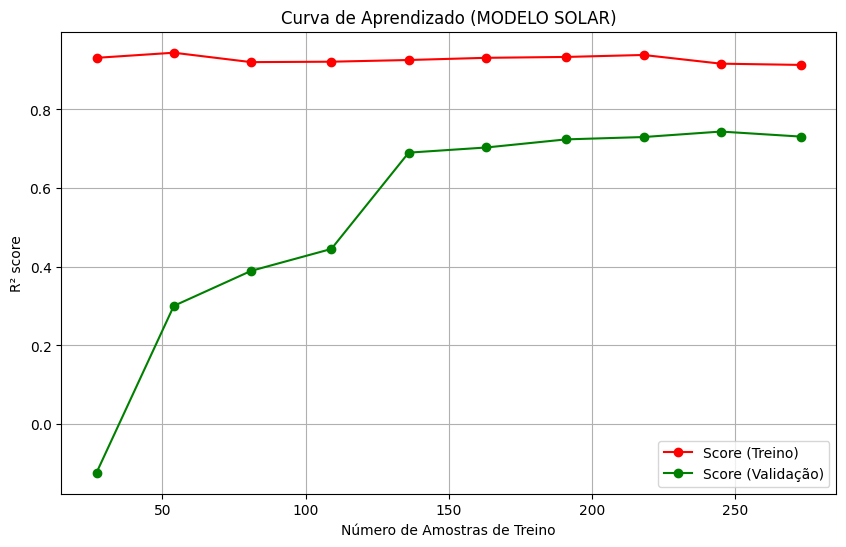


--- Importância das Features (SOLAR) ---
                 Feature    Importance
2           centroid_lat  3.951638e-01
6      vento_media_anual  3.946068e-01
7       temp_media_anual  1.696964e-01
1           centroid_lon  3.589136e-02
0               area_km2  3.331008e-03
5  km_linhas_transmissao  9.600212e-04
3      potencia_total_mw  3.502449e-04
4      potencia_hidro_mw  4.280945e-07


/tmp/ipython-input-310924564.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_s, palette='viridis')


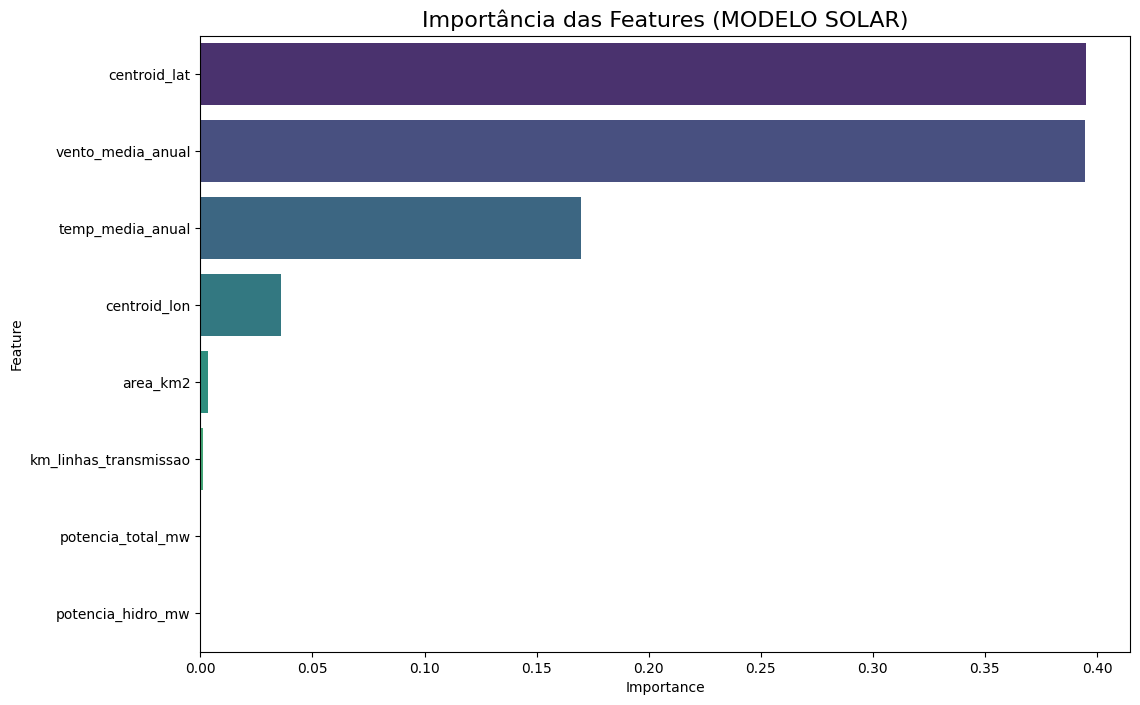

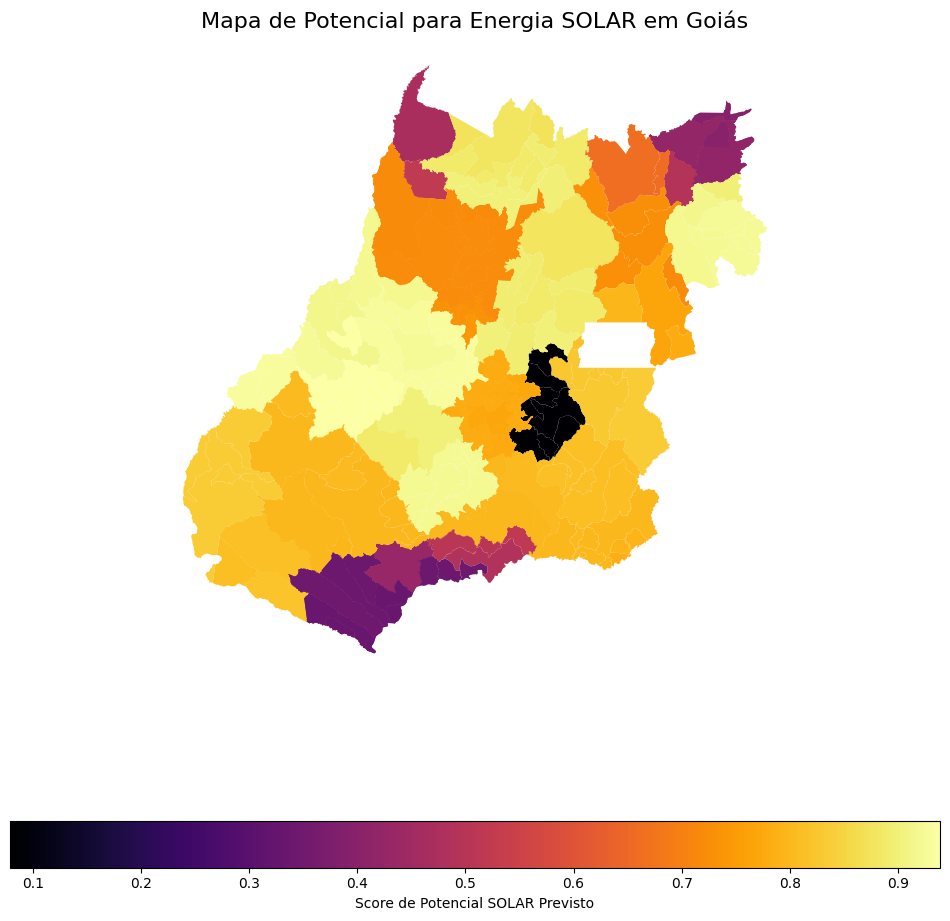


Top 10 Municípios para Investimento em Energia SOLAR:
                 nm_mun  predicted_potential_SOLAR
5               Diorama                   0.938804
152         Israelândia                   0.938804
217        Fazenda Nova                   0.938804
238   Santa Fé de Goiás                   0.938804
241        Amorinópolis                   0.938804
2    Palestina de Goiás                   0.938804
105          Arenópolis                   0.938804
102               Iporá                   0.938804
139           Ivolândia                   0.938804
177             Moiporá                   0.938804

--- Sinergia HIDRO-SOLAR ---
Municípios com Maior Sinergia Hidro-Solar (Prioridade Máxima):
                       nm_mun  predicted_potential_SOLAR  potencia_hidro_mw
2          Palestina de Goiás                   0.938804                0.0
5                     Diorama                   0.938804                0.0
16               Damianópolis                   0.922118       

['model_solar.joblib']

In [63]:
# --- 2. TREINAMENTO (SOLAR) ---
model_solar = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=5)
print("Treinando o modelo SOLAR...")
model_solar.fit(X_train_s, y_train_s)

# --- 3. AVALIAÇÃO (SOLAR) ---
y_pred_s = model_solar.predict(X_test_s)
r2_s = r2_score(y_test_s, y_pred_s)
print(f"\n--- Avaliação do Modelo SOLAR ---")
print(f"R-squared (R²) do Modelo SOLAR: {r2_s:.4f}")

# --- 4. CURVA DE APRENDIZADO (SOLAR) ---
print("Gerando curva de aprendizado SOLAR...")
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model_solar,
    X=X_solar,
    y=y_solar,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score (Treino)")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Score (Validação)")
plt.ylabel("R² score")
plt.xlabel("Número de Amostras de Treino")
plt.title("Curva de Aprendizado (MODELO SOLAR)")
plt.legend(loc="best")
plt.grid()
plt.savefig('learning_curve_SOLAR.png')
plt.show()

# --- 5. IMPORTÂNCIA DAS FEATURES (SOLAR) ---
importances_s = model_solar.feature_importances_
feature_importance_df_s = pd.DataFrame({
    'Feature': features_SOLAR,
    'Importance': importances_s
}).sort_values(by='Importance', ascending=False)

print("\n--- Importância das Features (SOLAR) ---")
print(feature_importance_df_s)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_s, palette='viridis')
plt.title('Importância das Features (MODELO SOLAR)', fontsize=16)
plt.savefig('feature_importance_SOLAR.png')
plt.show()

# --- 6. SALVAR PREDIÇÃO E GERAR MAPA (SOLAR) ---
df_modelo['predicted_potential_SOLAR'] = model_solar.predict(X_solar)

# Mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
df_modelo.plot(column='predicted_potential_SOLAR',
               ax=ax, legend=True, cmap='inferno',
               legend_kwds={'label': "Score de Potencial SOLAR Previsto", 'orientation': "horizontal"})
ax.set_axis_off()
ax.set_title('Mapa de Potencial para Energia SOLAR em Goiás', fontdict={'fontsize': '16', 'fontweight': '3'})
plt.savefig('mapa_potencial_SOLAR.png')
plt.show()

# Ranking
ranking_solar = df_modelo[['nm_mun', 'predicted_potential_SOLAR']].sort_values(by='predicted_potential_SOLAR', ascending=False)
print("\nTop 10 Municípios para Investimento em Energia SOLAR:")
print(ranking_solar.head(10))

# --- 7. ANÁLISE DE SINERGIA (SOLAR) ---
print("\n--- Sinergia HIDRO-SOLAR ---")
limiar_potencial_solar = df_modelo['predicted_potential_SOLAR'].quantile(0.75)
limiar_potencia_hidro = df_modelo['potencia_hidro_mw'].quantile(0.75)

zonas_de_sinergia_SOLAR = df_modelo[
    (df_modelo['predicted_potential_SOLAR'] >= limiar_potencial_solar) &
    (df_modelo['potencia_hidro_mw'] >= limiar_potencia_hidro)
]
print("Municípios com Maior Sinergia Hidro-Solar (Prioridade Máxima):")
print(zonas_de_sinergia_SOLAR[['nm_mun', 'predicted_potential_SOLAR', 'potencia_hidro_mw']])

print("Salvando modelo SOLAR...")
joblib.dump(model_solar, 'model_solar.joblib')


### Treinamento Modelo Eólico (Random Forest)

Treinando o modelo EÓLICO...

--- Avaliação do Modelo EÓLICO ---
R-squared (R²) do Modelo EÓLICO: 0.9218
Gerando curva de aprendizado EÓLICO...


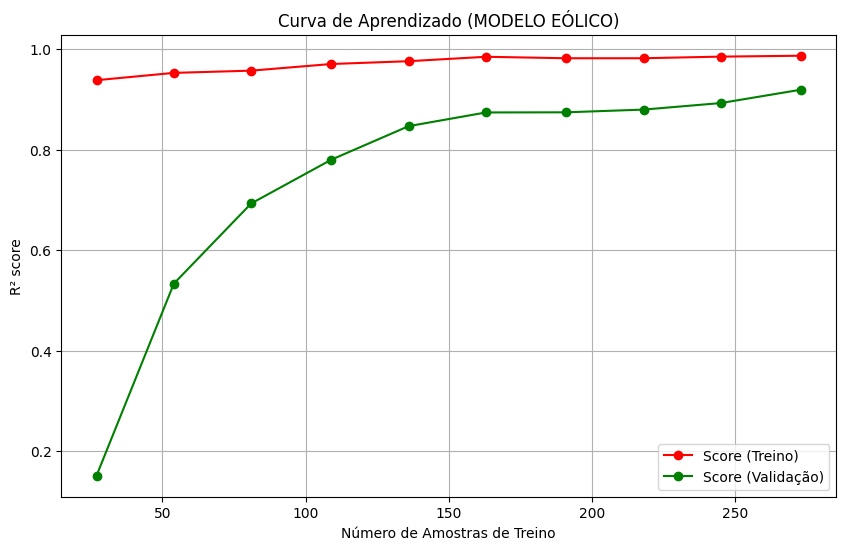


--- Importância das Features (EÓLICO) ---
                 Feature  Importance
2           centroid_lat    0.319617
6   radiacao_media_anual    0.279446
1           centroid_lon    0.212721
7       temp_media_anual    0.153807
0               area_km2    0.030725
5  km_linhas_transmissao    0.002266
3      potencia_total_mw    0.001225
4      potencia_hidro_mw    0.000191


/tmp/ipython-input-2775560488.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_e, palette='viridis')


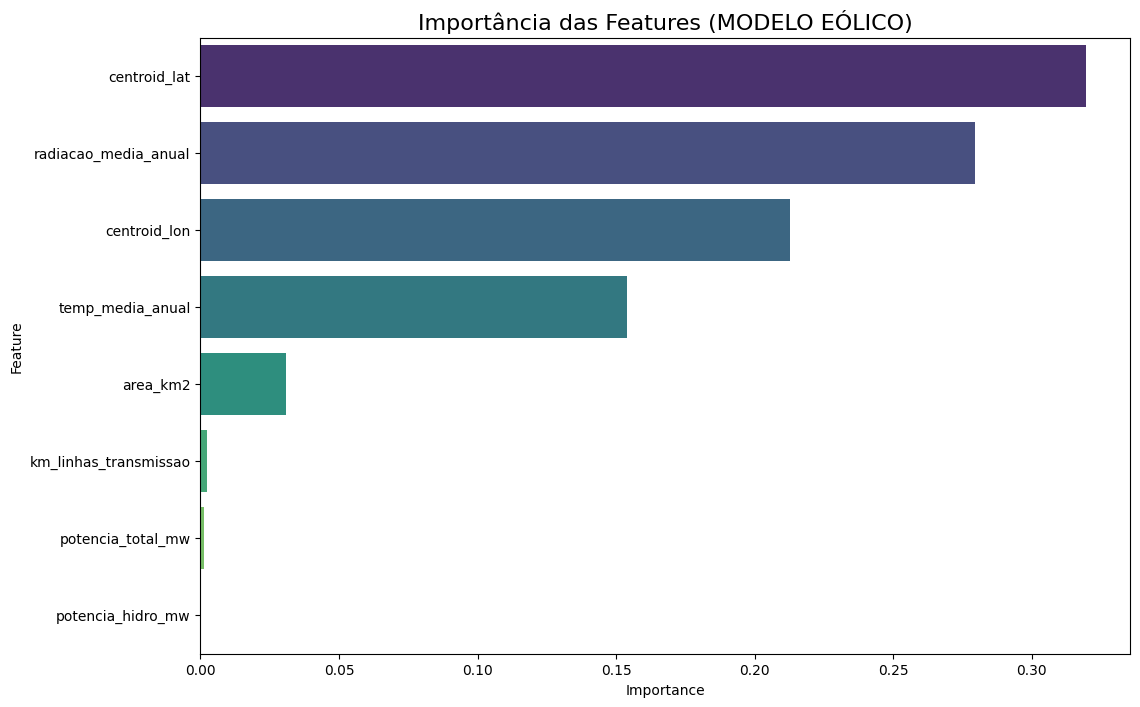

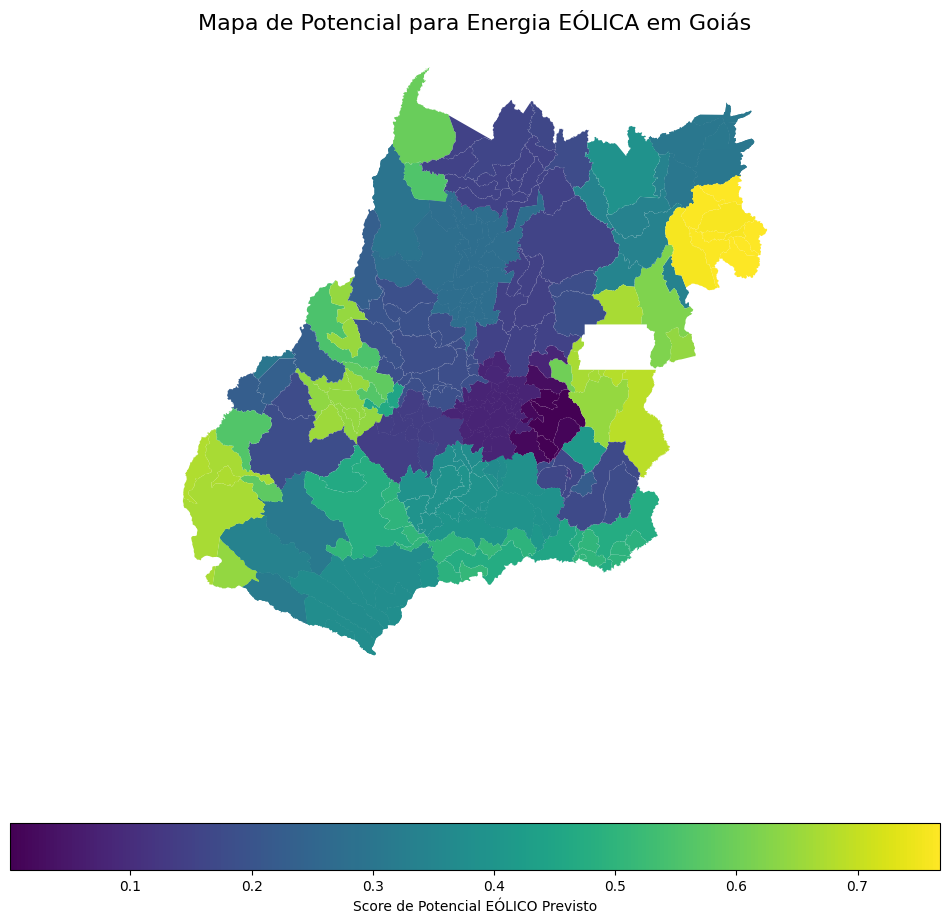


Top 10 Municípios para Investimento em Energia EÓLICA:
                nm_mun  predicted_potential_EOLICO
63      Sítio d'Abadia                    0.768070
16        Damianópolis                    0.768070
244             Mambaí                    0.768070
218   Guarani de Goiás                    0.768070
194         Simolândia                    0.764385
19   Alvorada do Norte                    0.764385
249            Iaciara                    0.764385
150      Buritinópolis                    0.761408
239              Posse                    0.761408
321    Flores de Goiás                    0.756091
Salvando modelo EÓLICO...


In [64]:
# --- 2. TREINAMENTO (EÓLICO) ---
model_eolico = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=7)
print("Treinando o modelo EÓLICO...")
model_eolico.fit(X_train_e, y_train_e)

# --- 3. AVALIAÇÃO (EÓLICO) ---
y_pred_e = model_eolico.predict(X_test_e)
r2_e = r2_score(y_test_e, y_pred_e)
print(f"\n--- Avaliação do Modelo EÓLICO ---")
print(f"R-squared (R²) do Modelo EÓLICO: {r2_e:.4f}")

# --- 4. CURVA DE APRENDIZADO (EÓLICO) ---
print("Gerando curva de aprendizado EÓLICO...")
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model_eolico,
    X=X_eolico,
    y=y_eolico,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score (Treino)")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Score (Validação)")
plt.ylabel("R² score")
plt.xlabel("Número de Amostras de Treino")
plt.title("Curva de Aprendizado (MODELO EÓLICO)")
plt.legend(loc="best")
plt.grid()
plt.savefig('learning_curve_EOLICO.png')
plt.show()

# --- 5. IMPORTÂNCIA DAS FEATURES (EÓLICO) ---
importances_e = model_eolico.feature_importances_
feature_importance_df_e = pd.DataFrame({
    'Feature': features_EOLICO,
    'Importance': importances_e
}).sort_values(by='Importance', ascending=False)

print("\n--- Importância das Features (EÓLICO) ---")
print(feature_importance_df_e)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_e, palette='viridis')
plt.title('Importância das Features (MODELO EÓLICO)', fontsize=16)
plt.savefig('feature_importance_EOLICO.png')
plt.show()

# --- 6. SALVAR PREDIÇÃO E GERAR MAPA (EÓLICO) ---
df_modelo['predicted_potential_EOLICO'] = model_eolico.predict(X_eolico)

# Mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
df_modelo.plot(column='predicted_potential_EOLICO',
               ax=ax, legend=True, cmap='viridis',  # Mudei o cmap para diferenciar
               legend_kwds={'label': "Score de Potencial EÓLICO Previsto", 'orientation': "horizontal"})
ax.set_axis_off()
ax.set_title('Mapa de Potencial para Energia EÓLICA em Goiás', fontdict={'fontsize': '16', 'fontweight': '3'})
plt.savefig('mapa_potencial_EOLICO.png')
plt.show()

# Ranking
ranking_eolico = df_modelo[['nm_mun', 'predicted_potential_EOLICO']].sort_values(by='predicted_potential_EOLICO', ascending=False)
print("\nTop 10 Municípios para Investimento em Energia EÓLICA:")
print(ranking_eolico.head(10))

print("Salvando modelo EÓLICO...")
joblib.dump(model_eolico, 'model_eolico.joblib')

df_modelo.to_parquet('df_modelo_final.parquet')

### Treinamento Modelo Solar (Rede Neural)

Formato dos dados de treino X: (273, 8)
Treinando o modelo SOLAR (Rede Neural)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinamento concluído!
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

--- Avaliação do Modelo SOLAR (Rede Neural) ---
R-squared (R²) do Modelo SOLAR: 0.0750
Gerando curva de Loss SOLAR...


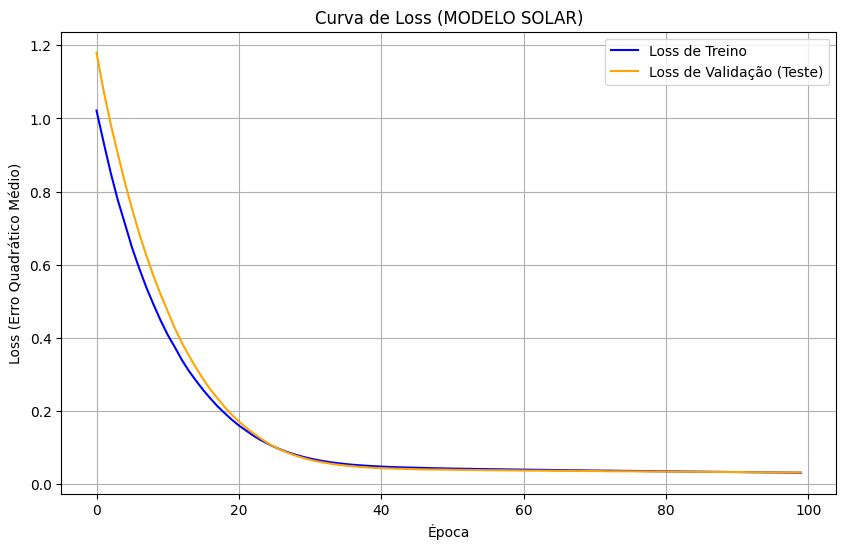

In [65]:
# --- 2. NORMALIZAÇÃO (SCALING) ---
# Essencial para Redes Neurais
scaler_solar = StandardScaler()
X_train_s = scaler_solar.fit_transform(X_train_s)
X_test_s = scaler_solar.transform(X_test_s)
X_solar_scaled = scaler_solar.transform(X_solar) # Para predição final

print(f"Formato dos dados de treino X: {X_train_s.shape}")

# --- 3. CONSTRUIR MODELO (SOLAR) ---
model_solar_nn = Sequential([
    # Camada oculta com 10 neurônios, função tanh, e input_shape correto
    Dense(10, activation='tanh', input_shape=(X_train_s.shape[1],)),
    Dense(1)  # Camada de saída (prevê 1 número)
])
model_solar_nn.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. TREINAMENTO (SOLAR) ---
print("Treinando o modelo SOLAR (Rede Neural)...")
history_solar = model_solar_nn.fit(
    X_train_s,
    y_train_s,
    epochs=100,
    validation_data=(X_test_s, y_test_s), # Usa o set de teste para validação
    verbose=0
)
print("Treinamento concluído!")

# --- 5. AVALIAÇÃO (SOLAR) ---
y_pred_s = model_solar_nn.predict(X_test_s)
r2_s = r2_score(y_test_s, y_pred_s)
print(f"\n--- Avaliação do Modelo SOLAR (Rede Neural) ---")
print(f"R-squared (R²) do Modelo SOLAR: {r2_s:.4f}")

# --- 6. CURVA DE LOSS (SOLAR) ---
print("Gerando curva de Loss SOLAR...")
plt.figure(figsize=(10, 6))
plt.plot(history_solar.history['loss'], label='Loss de Treino', color='blue')
plt.plot(history_solar.history['val_loss'], label='Loss de Validação (Teste)', color='orange')
plt.title('Curva de Loss (MODELO SOLAR)')
plt.xlabel('Época')
plt.ylabel('Loss (Erro Quadrático Médio)')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve_SOLAR.png')
plt.show()

### Treinamento Modelo Eólico (Rede Neural)

Formato dos dados de treino X: (273, 8)
Treinando o modelo EÓLICO (Rede Neural)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinamento concluído!
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

--- Avaliação do Modelo EÓLICO (Rede Neural) ---
R-squared (R²) do Modelo EÓLICO: 0.2625
Gerando curva de Loss EÓLICO...


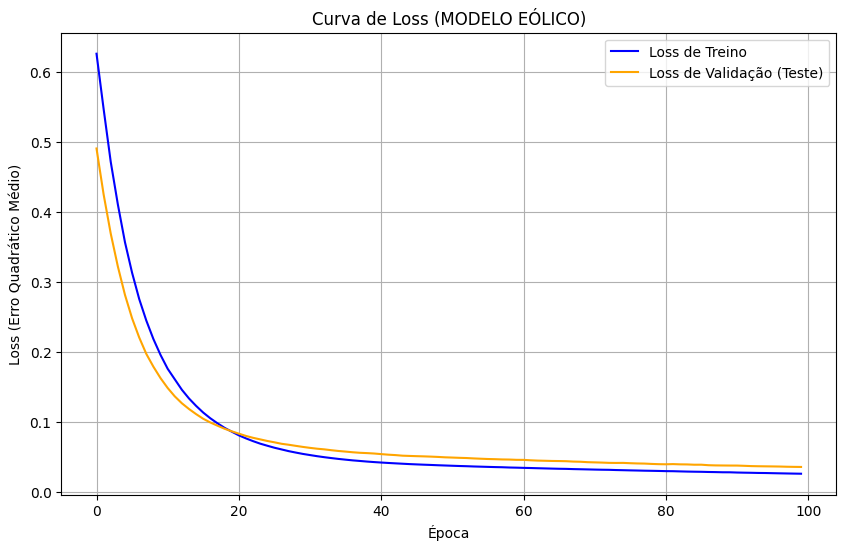

In [66]:
# --- 2. NORMALIZAÇÃO (SCALING) ---
scaler_eolico = StandardScaler()
X_train_e = scaler_eolico.fit_transform(X_train_e)
X_test_e = scaler_eolico.transform(X_test_e)
X_eolico_scaled = scaler_eolico.transform(X_eolico) # Para predição final

print(f"Formato dos dados de treino X: {X_train_e.shape}")

# --- 3. CONSTRUIR MODELO (EÓLICO) ---
model_eolico_nn = Sequential([
    Dense(10, activation='tanh', input_shape=(X_train_e.shape[1],)),
    Dense(1)
])
model_eolico_nn.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. TREINAMENTO (EÓLICO) ---
print("Treinando o modelo EÓLICO (Rede Neural)...")
history_eolico = model_eolico_nn.fit(
    X_train_e,
    y_train_e,
    epochs=100,
    validation_data=(X_test_e, y_test_e),
    verbose=0
)
print("Treinamento concluído!")

# --- 5. AVALIAÇÃO (EÓLICO) ---
y_pred_e = model_eolico_nn.predict(X_test_e)
r2_e = r2_score(y_test_e, y_pred_e)
print(f"\n--- Avaliação do Modelo EÓLICO (Rede Neural) ---")
print(f"R-squared (R²) do Modelo EÓLICO: {r2_e:.4f}")

# --- 6. CURVA DE LOSS (EÓLICO) ---
print("Gerando curva de Loss EÓLICO...")
plt.figure(figsize=(10, 6))
plt.plot(history_eolico.history['loss'], label='Loss de Treino', color='blue')
plt.plot(history_eolico.history['val_loss'], label='Loss de Validação (Teste)', color='orange')
plt.title('Curva de Loss (MODELO EÓLICO)')
plt.xlabel('Época')
plt.ylabel('Loss (Erro Quadrático Médio)')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve_EOLICO.png')
plt.show()


--- Gerando gráficos de Capacidade de Escoamento vs Potencial ---


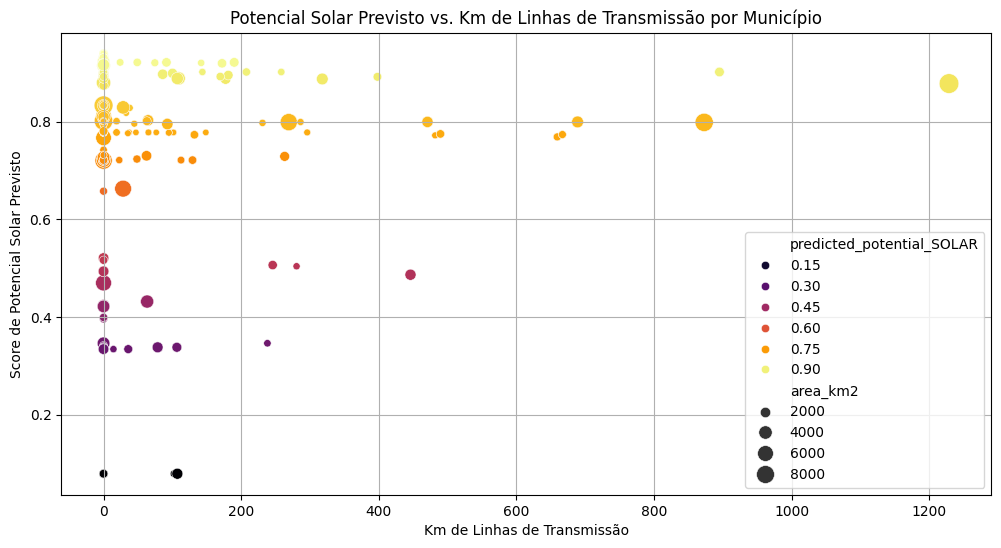

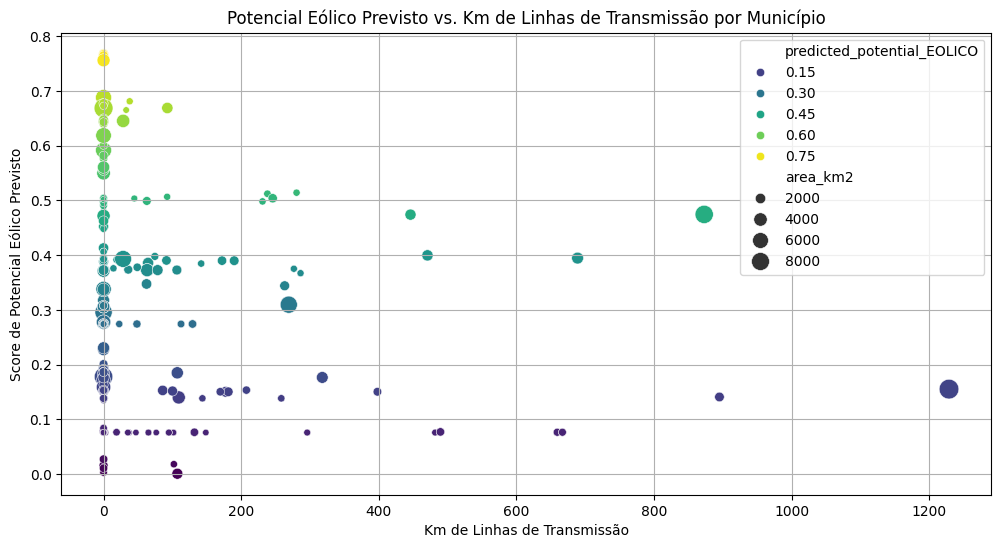

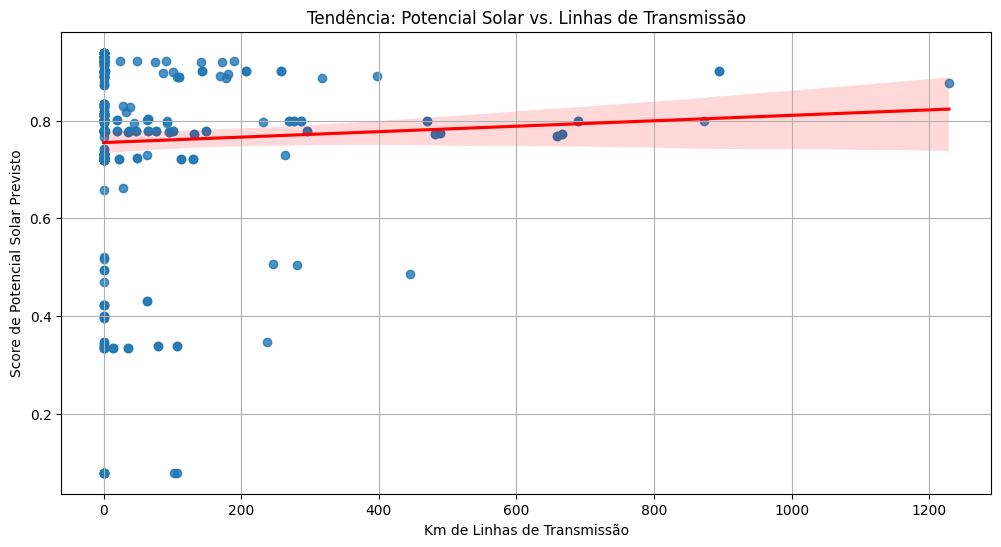

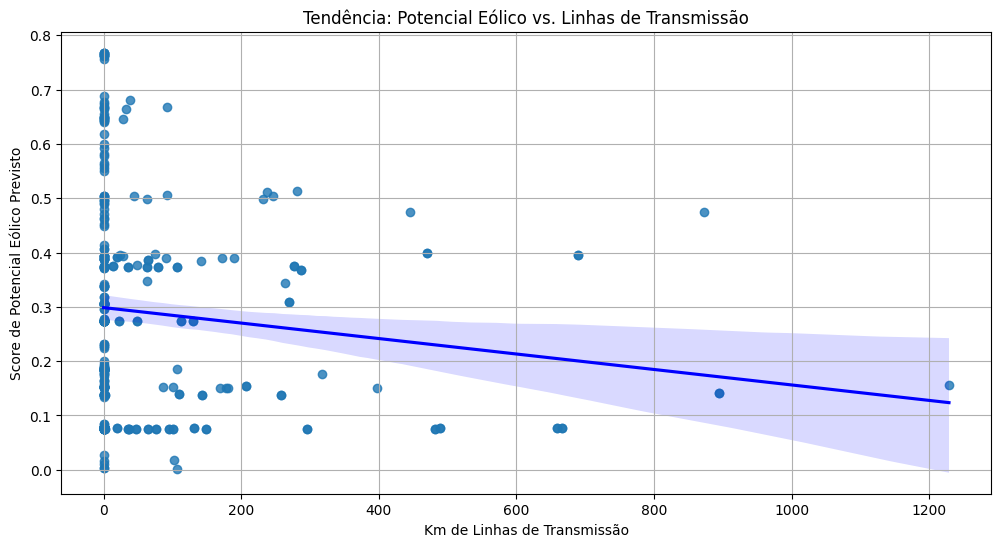

In [67]:
# ==============================================================================
# ANÁLISE VISUAL: CAPACIDADE DE ESCOAMENTO vs POTENCIAL PREVISTO
# ==============================================================================

print("\n--- Gerando gráficos de Capacidade de Escoamento vs Potencial ---")

# --- Gráfico 1: Scatter Plot (SOLAR) ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_modelo, x='km_linhas_transmissao', y='predicted_potential_SOLAR', hue='predicted_potential_SOLAR', palette='inferno', size='area_km2', sizes=(20, 200))
plt.title('Potencial Solar Previsto vs. Km de Linhas de Transmissão por Município')
plt.xlabel('Km de Linhas de Transmissão')
plt.ylabel('Score de Potencial Solar Previsto')
plt.grid(True)
plt.savefig('scatter_transmissao_vs_solar.png')
plt.show()

# --- Gráfico 2: Scatter Plot (EÓLICO) ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_modelo, x='km_linhas_transmissao', y='predicted_potential_EOLICO', hue='predicted_potential_EOLICO', palette='viridis', size='area_km2', sizes=(20, 200))
plt.title('Potencial Eólico Previsto vs. Km de Linhas de Transmissão por Município')
plt.xlabel('Km de Linhas de Transmissão')
plt.ylabel('Score de Potencial Eólico Previsto')
plt.grid(True)
plt.savefig('scatter_transmissao_vs_eolico.png')
plt.show()

# --- Gráfico 3: Regressão Plot (para ver a tendência - Opcional, mas útil) ---
plt.figure(figsize=(12, 6))
sns.regplot(data=df_modelo, x='km_linhas_transmissao', y='predicted_potential_SOLAR', line_kws={"color": "red"})
plt.title('Tendência: Potencial Solar vs. Linhas de Transmissão')
plt.xlabel('Km de Linhas de Transmissão')
plt.ylabel('Score de Potencial Solar Previsto')
plt.grid(True)
plt.savefig('regplot_transmissao_vs_solar.png')
plt.show()

plt.figure(figsize=(12, 6))
sns.regplot(data=df_modelo, x='km_linhas_transmissao', y='predicted_potential_EOLICO', line_kws={"color": "blue"})
plt.title('Tendência: Potencial Eólico vs. Linhas de Transmissão')
plt.xlabel('Km de Linhas de Transmissão')
plt.ylabel('Score de Potencial Eólico Previsto')
plt.grid(True)
plt.savefig('regplot_transmissao_vs_eolico.png')
plt.show()

In [68]:
# ==============================================================================
# PASSO 3.6: AGREGAR CAPACIDADE DE TRANSMISSÃO POR MUNICÍPIO
# ==============================================================================

# Verifica se gdf_linhas_clipped foi criado com sucesso e não está vazio
if 'gdf_linhas_clipped' in locals() and not gdf_linhas_clipped.empty:
    print("\n--- Calculando Capacidade Média e Máxima de Transmissão por Município ---")

    # Seleciona a coluna de capacidade de interesse
    col_capacidade = 'val_capacoperlongasemlimit'

    # Garante que a coluna existe e é numérica, tratando erros e NaNs
    if col_capacidade in gdf_linhas_clipped.columns:
        # Tenta converter para numérico, substituindo vírgulas e tratando erros
        gdf_linhas_clipped[col_capacidade] = pd.to_numeric(
            gdf_linhas_clipped[col_capacidade].astype(str).str.replace(',', '.'),
            errors='coerce'
        )
        # Remove linhas onde a capacidade é NaN após a conversão
        gdf_capacidade_valida = gdf_linhas_clipped.dropna(subset=[col_capacidade])

        if not gdf_capacidade_valida.empty:
            # Agrupa por município e calcula a média e o máximo da capacidade
            capacidade_agg = gdf_capacidade_valida.groupby('cd_mun')[col_capacidade].agg(['mean', 'max']).reset_index()

            # Renomeia as colunas agregadas
            capacidade_agg = capacidade_agg.rename(columns={
                'mean': 'capacidade_media_mw',
                'max': 'capacidade_maxima_mw'
            })

            # --- Merge com df_final ---
            # Remove colunas antigas se existirem para evitar conflitos
            cols_cap_to_drop = ['capacidade_media_mw', 'capacidade_maxima_mw']
            cols_cap_existentes = [col for col in cols_cap_to_drop if col in df_final.columns]
            if cols_cap_existentes:
                df_final = df_final.drop(columns=cols_cap_existentes)

            # Junta as novas métricas de capacidade ao df_final
            df_final = df_final.merge(capacidade_agg, on='cd_mun', how='left')

            # Preenche com 0 municípios sem linhas de transmissão com capacidade válida
            df_final[['capacidade_media_mw', 'capacidade_maxima_mw']] = df_final[['capacidade_media_mw', 'capacidade_maxima_mw']].fillna(0)

            print("Capacidade Média e Máxima adicionadas ao df_final:")
            display(df_final[['nm_mun', 'km_linhas_transmissao', 'capacidade_media_mw', 'capacidade_maxima_mw']].head())

        else:
            print(f"Aviso: Nenhuma linha com valor numérico válido encontrado na coluna '{col_capacidade}'. Adicionando colunas de capacidade com zeros.")
            df_final['capacidade_media_mw'] = 0.0
            df_final['capacidade_maxima_mw'] = 0.0

    else:
        print(f"ERRO: Coluna '{col_capacidade}' não encontrada em gdf_linhas_clipped. Não foi possível calcular a capacidade agregada.")
        # Adiciona colunas com 0 para não quebrar etapas futuras
        df_final['capacidade_media_mw'] = 0.0
        df_final['capacidade_maxima_mw'] = 0.0

else:
    print("ERRO: GeoDataFrame 'gdf_linhas_clipped' não foi encontrado ou está vazio. Não foi possível calcular a capacidade agregada.")
    # Adiciona colunas com 0
    df_final['capacidade_media_mw'] = 0.0
    df_final['capacidade_maxima_mw'] = 0.0


--- Calculando Capacidade Média e Máxima de Transmissão por Município ---
Capacidade Média e Máxima adicionadas ao df_final:


,nm_mun,km_linhas_transmissao,capacidade_media_mw,capacidade_maxima_mw
0,São Francisco de Goiás,0.000000,0.0,0.0
1,São Francisco de Goiás,0.000000,0.0,0.0
2,Palestina de Goiás,0.000000,0.0,0.0
3,Goianápolis,101.583939,911.0,1428.0
4,Goianápolis,101.583939,911.0,1428.0
